# 🛡️ CIC-IDS2017 Network Anomaly Detection System
## Three-Stage Pipeline: LightGBM → XGBoost → Autoencoder
---
**Author:** CyberAI Network  
**Dataset:** CIC-IDS2017 (Kaggle)  
**Hardware:** Kaggle T4×2 GPU  

### Pipeline Architecture
| Stage | Model | Task |
|---|---|---|
| Stage 1 | **LightGBM** | Binary gate — BENIGN vs ATTACK (fast, GPU) |
| Stage 2 | **XGBoost multiclass** | Which attack type? (accurate, GPU) |
| Stage 3 | **Autoencoder (PyTorch)** | Zero-day detection — known vs novel attack |

> Each stage does exactly what it is best at. LightGBM handles volume at Stage 1 (<0.5 ms/flow). XGBoost delivers the best per-class F1 on rare attack types at Stage 2. The autoencoder catches patterns no classifier can flag — attacks that do not resemble anything in the training set.


## 1. Environment Setup & GPU Verification
### What this does
Imports all required libraries and verifies GPU availability (Kaggle T4×2).
### Why
We need GPU for deep learning training. Verifying early prevents silent CPU fallback.
### Expected output
List of available GPUs and CUDA version.

In [45]:
import os, sys, warnings, gc, glob, time, pickle, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_fscore_support,
    accuracy_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='viridis')
plt.rcParams.update({'figure.figsize':(12,6),'font.size':12})

# GPU check
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    n_gpu = torch.cuda.device_count()
    for i in range(n_gpu):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
    print("WARNING: No GPU found, using CPU")
print(f"Active device: {DEVICE}")

PyTorch: 2.10.0+cu128
CUDA available: True
  GPU 0: Tesla T4
  GPU 1: Tesla T4
Active device: cuda


## 2. Data Loading
### What this does
Loads all Parquet files from the CIC-IDS2017 dataset and merges them into a single DataFrame.
### Why
The dataset is split across multiple Parquet files (one per day). Merging gives a unified view. Parquet is columnar and significantly faster to load than CSV.
### Expected output
Shape of merged DataFrame and column names.


In [46]:
INPUT_DIR = '/kaggle/input/'
print("Available datasets:", os.listdir(INPUT_DIR))

dataset_dir = None
for d in os.listdir(INPUT_DIR):
    full = os.path.join(INPUT_DIR, d)
    if os.path.isdir(full):
        dataset_dir = full
        break

print(f"Dataset directory: {dataset_dir}")

# Find all parquet files (dataset uses .parquet format)
parquet_files = glob.glob(os.path.join(dataset_dir, '**', '*.parquet'), recursive=True)
print(f"Found {len(parquet_files)} Parquet files:")
for f in parquet_files:
    print(f"  {os.path.basename(f)}")

dfs = []
for f in parquet_files:
    print(f"Loading {os.path.basename(f)}...", end=" ")
    df_tmp = pd.read_parquet(f)
    print(f"shape={df_tmp.shape}")
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)
df.columns = df.columns.str.strip()
print(f"\nMerged DataFrame: {df.shape}")
print(f"Columns ({len(df.columns)}):")
print(df.columns.tolist())
del dfs; gc.collect()


Available datasets: ['datasets']
Dataset directory: /kaggle/input/datasets
Found 8 Parquet files:
  Benign-Monday-no-metadata.parquet
  Bruteforce-Tuesday-no-metadata.parquet
  Portscan-Friday-no-metadata.parquet
  WebAttacks-Thursday-no-metadata.parquet
  DoS-Wednesday-no-metadata.parquet
  DDoS-Friday-no-metadata.parquet
  Infiltration-Thursday-no-metadata.parquet
  Botnet-Friday-no-metadata.parquet
Loading Benign-Monday-no-metadata.parquet... shape=(458831, 78)
Loading Bruteforce-Tuesday-no-metadata.parquet... shape=(389714, 78)
Loading Portscan-Friday-no-metadata.parquet... shape=(119522, 78)
Loading WebAttacks-Thursday-no-metadata.parquet... shape=(155820, 78)
Loading DoS-Wednesday-no-metadata.parquet... shape=(584991, 78)
Loading DDoS-Friday-no-metadata.parquet... shape=(221264, 78)
Loading Infiltration-Thursday-no-metadata.parquet... shape=(207630, 78)
Loading Botnet-Friday-no-metadata.parquet... shape=(176038, 78)

Merged DataFrame: (2313810, 78)
Columns (78):
['Protocol', 'Flo

84529

## 3. Exploratory Data Analysis
### 3.1 Dataset Overview
### What this does
Shows basic info: dtypes, sample rows, and summary statistics.
### Why
Understanding data shape and types guides preprocessing decisions.
### Expected output
First 5 rows, info summary, and describe output.

In [47]:

print("Shape:", df.shape)
print("\nDtypes value counts:")
print(df.dtypes.value_counts())
print("\nSample rows:")
df.head(5)

Shape: (2313810, 78)

Dtypes value counts:
int32      26
float32    22
int8       19
int16       7
float64     2
int64       1
object      1
Name: count, dtype: int64

Sample rows:


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,4,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,6,3,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,6,609,7,4,484,414,233,0,69.14286,111.967896,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


### 3.2 Label Distribution
### What this does
Analyzes the class distribution of the Label column.
### Why
CIC-IDS2017 is heavily imbalanced; understanding this guides sampling strategy.
### Expected output
Bar chart of class distribution and exact counts.

Class distribution:
Label
Benign                        1977318
DoS Hulk                       172846
DDoS                           128014
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
PortScan                         1956
Web Attack � Brute Force         1470
Bot                              1437
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Total samples: 2313810
Benign %: 0.0%


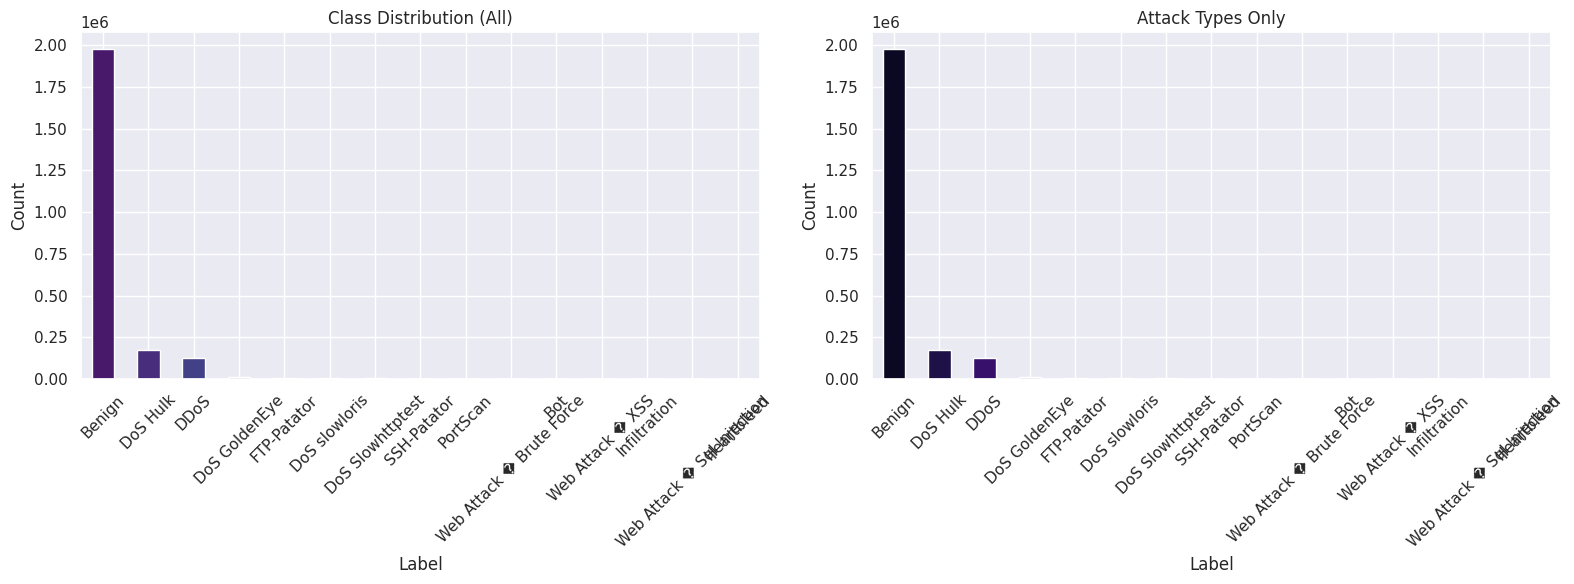

In [48]:
label_col = 'Label'
print("Class distribution:")
label_counts = df[label_col].value_counts()
print(label_counts)
print(f"\nTotal samples: {len(df)}")
print(f"Benign %: {(df[label_col]=='BENIGN').mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
label_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('viridis', len(label_counts)))
axes[0].set_title('Class Distribution (All)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

attack_counts = label_counts.drop('BENIGN', errors='ignore')
attack_counts.plot(kind='bar', ax=axes[1], color=sns.color_palette('magma', len(attack_counts)))
axes[1].set_title('Attack Types Only')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 3.3 Feature Distributions
### What this does
Plots distributions of key numeric features.
### Why
Reveals skewness, outliers, and scale differences that inform normalization.
### Expected output
Histograms for selected features.

Numeric features: 77


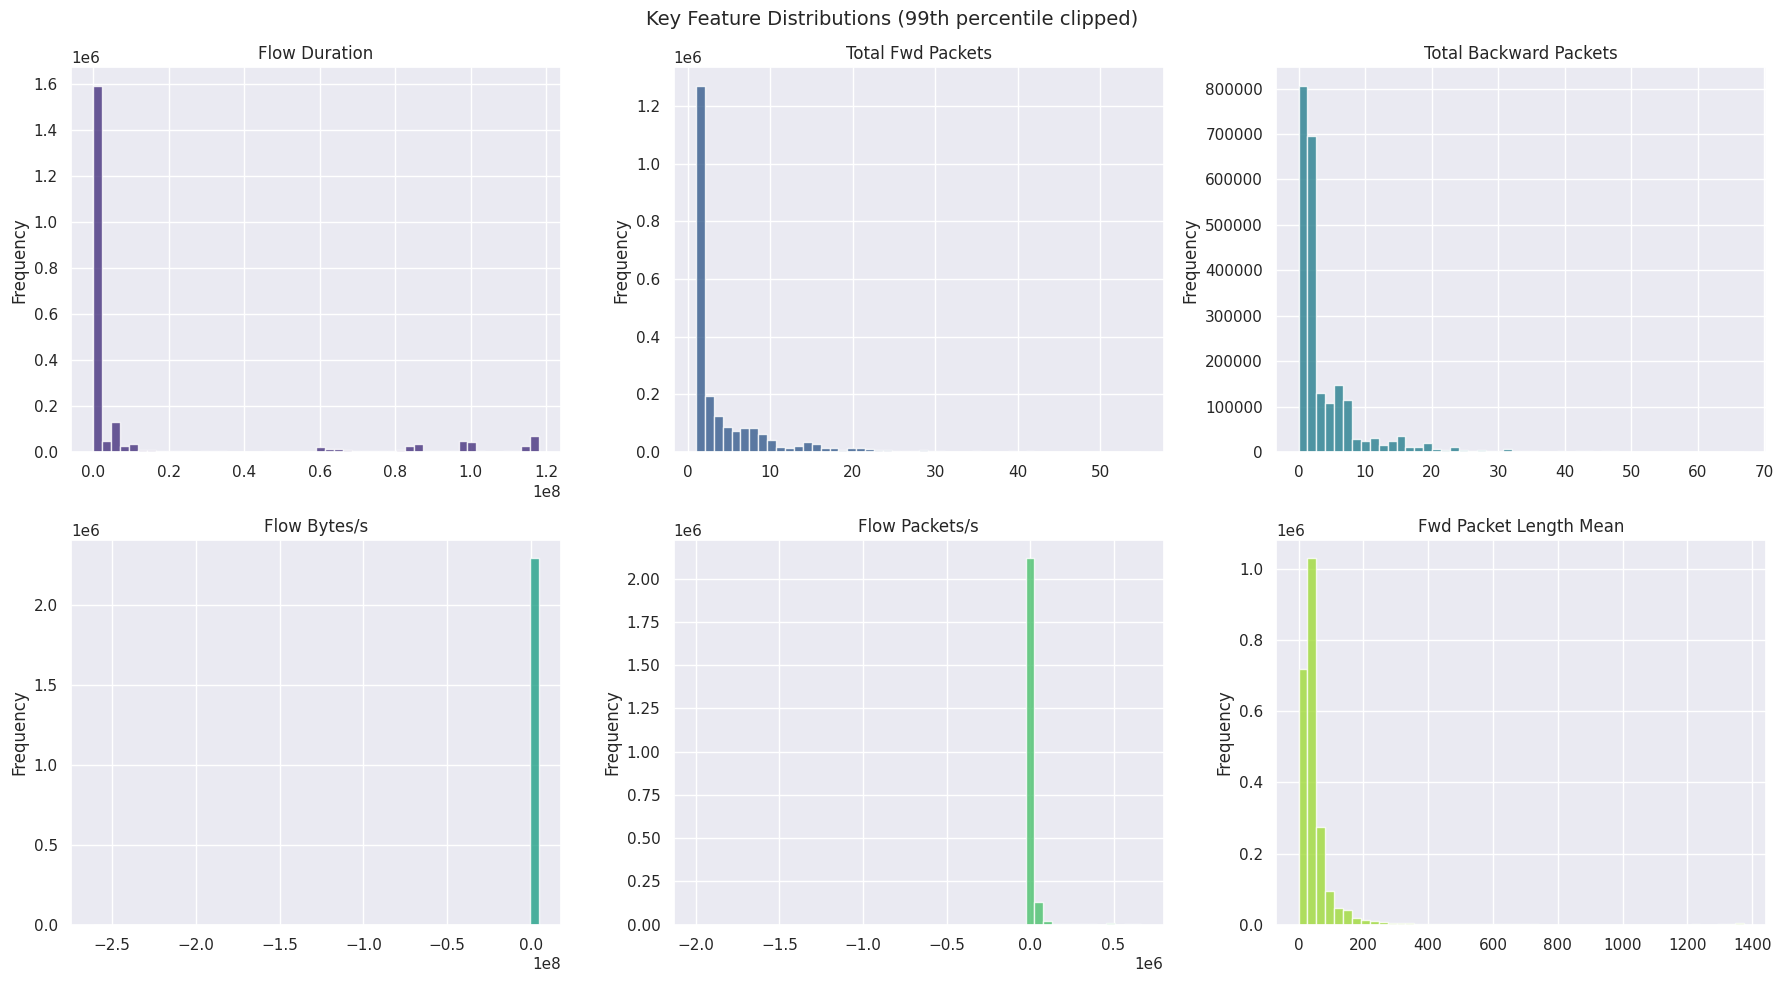

In [49]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric features: {len(numeric_cols)}")

key_features = ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Flow Bytes/s', 'Flow Packets/s', 'Fwd Packet Length Mean',
    'Bwd Packet Length Mean', 'Flow IAT Mean']
plot_feats = [f for f in key_features if f in numeric_cols][:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, feat in enumerate(plot_feats):
    ax = axes[i//3][i%3]
    data = df[feat].replace([np.inf, -np.inf], np.nan).dropna()
    data = data[data <= data.quantile(0.99)]  # clip outliers for viz
    ax.hist(data, bins=50, color=sns.color_palette('viridis')[i], alpha=0.8)
    ax.set_title(feat)
    ax.set_ylabel('Frequency')
plt.suptitle('Key Feature Distributions (99th percentile clipped)', fontsize=14)
plt.tight_layout()
plt.show()

### 3.4 Correlation Analysis
### What this does
Computes and visualizes correlation matrix for top features.
### Why
Identifies redundant features for removal in feature engineering.
### Expected output
Correlation heatmap.

Highly correlated pairs (|r|>0.95): 33
  Flow Duration <-> Fwd IAT Total: 0.999
  Total Fwd Packets <-> Bwd Packets Length Total: 0.956
  Total Fwd Packets <-> Fwd Header Length: 0.964
  Total Fwd Packets <-> Subflow Fwd Packets: 1.000
  Total Fwd Packets <-> Subflow Bwd Bytes: 0.956
  Total Backward Packets <-> Bwd Header Length: 0.976
  Total Backward Packets <-> Subflow Bwd Packets: 1.000
  Fwd Packets Length Total <-> Subflow Fwd Bytes: 1.000
  Bwd Packets Length Total <-> Subflow Fwd Packets: 0.956
  Bwd Packets Length Total <-> Subflow Bwd Bytes: 1.000


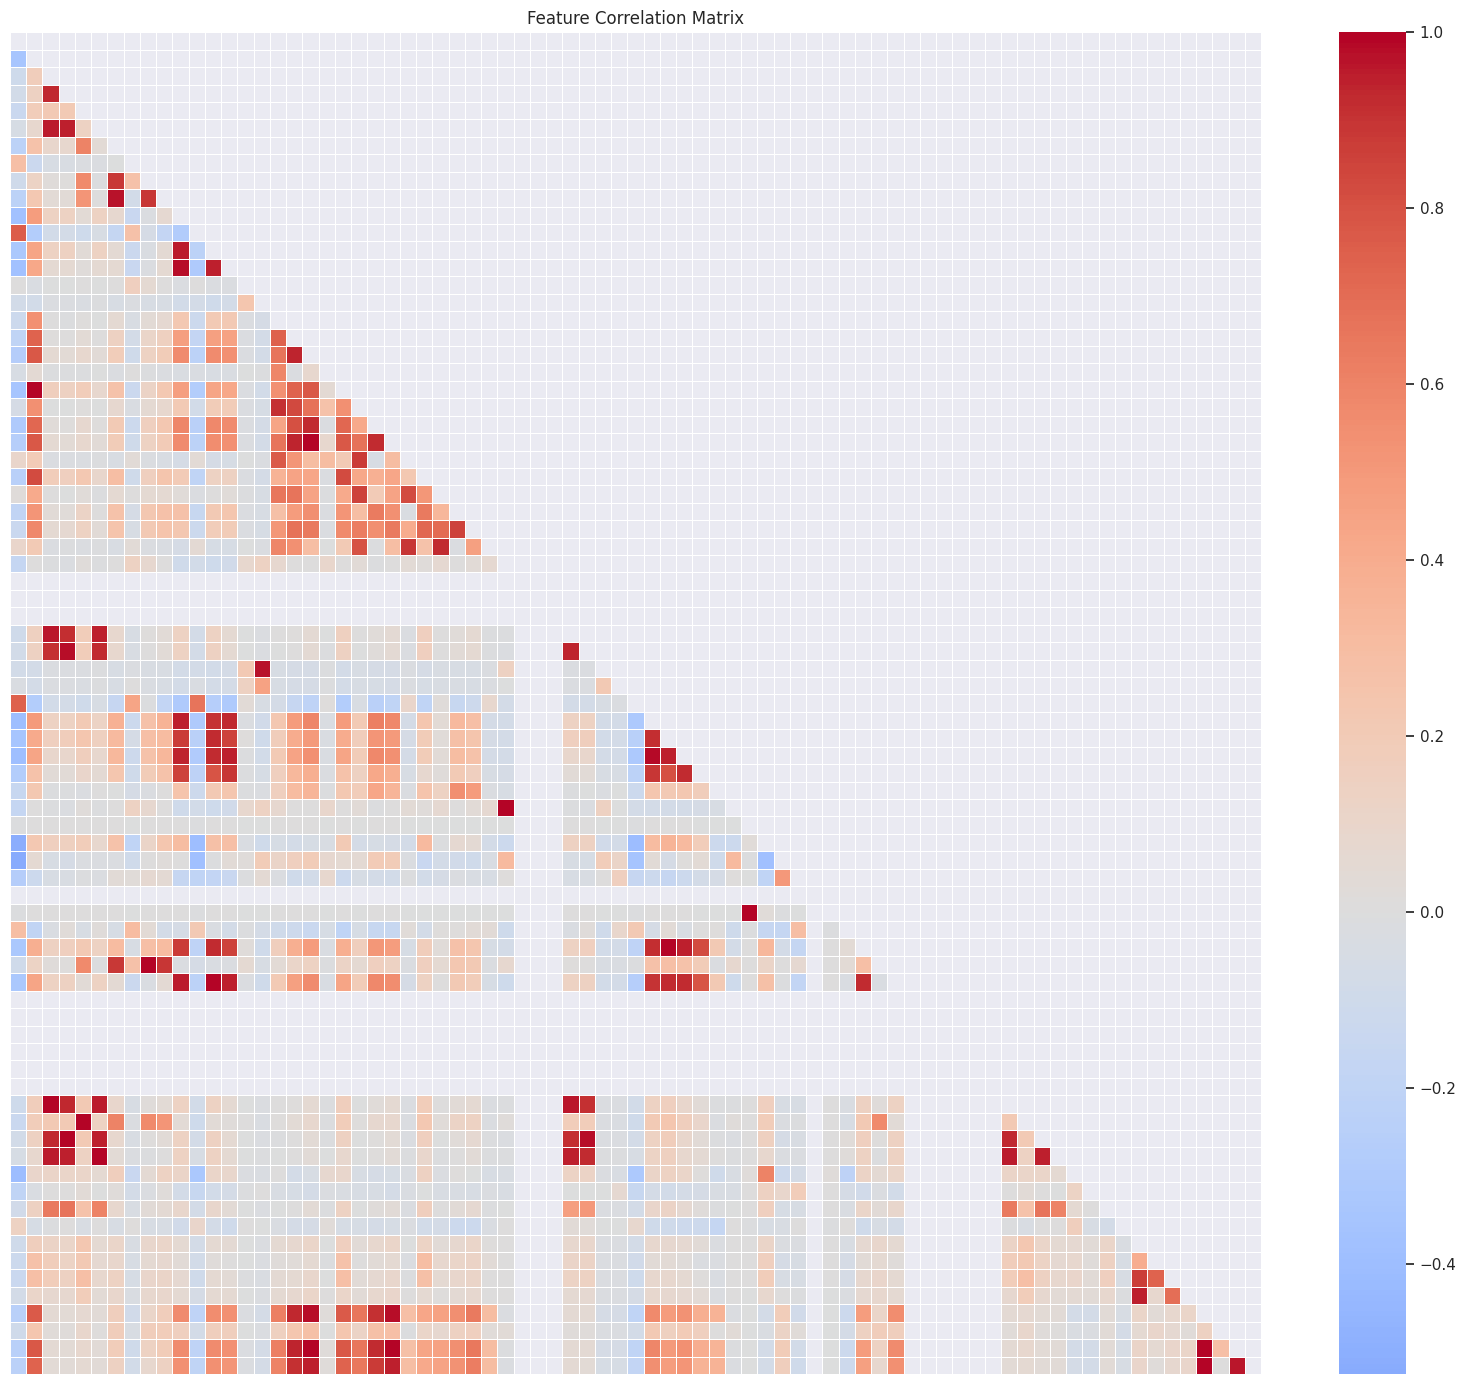

36978

In [50]:
sample_df = df[numeric_cols].replace([np.inf, -np.inf], np.nan).dropna().sample(
    min(50000, len(df)), random_state=42)
corr = sample_df.corr()

# Find highly correlated pairs
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i,j]) > 0.95:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i,j]))
print(f"Highly correlated pairs (|r|>0.95): {len(high_corr_pairs)}")
for c1,c2,r in high_corr_pairs[:10]:
    print(f"  {c1} <-> {c2}: {r:.3f}")

plt.figure(figsize=(16,14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, linewidths=0.5,
    xticklabels=False, yticklabels=False)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()
del sample_df; gc.collect()

## 4. Data Preprocessing
### 4.1 Handle Missing Values & Infinities
### What this does
Replaces infinities with NaN, drops rows with missing values, and removes duplicates.
### Why
ML models cannot handle inf/NaN. Duplicates bias the model.
### Expected output
Shape before/after cleaning.

In [51]:
print(f"Before cleaning: {df.shape}")

# Replace inf
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Count missing
missing = df.isnull().sum()
missing_cols = missing[missing > 0]
print(f"Columns with missing values: {len(missing_cols)}")
if len(missing_cols) > 0:
    print(missing_cols)

# Drop rows with NaN
df.dropna(inplace=True)
print(f"After dropping NaN: {df.shape}")

# Remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Removed {before - len(df)} duplicates. Final: {df.shape}")
gc.collect()

Before cleaning: (2313810, 78)
Columns with missing values: 0
After dropping NaN: (2313810, 78)
Removed 82004 duplicates. Final: (2231806, 78)


0

### 4.1b Class Grouping 
**Why:**  
The `Heartbleed` (11 samples) and `Infiltration` (36 samples) classes are too underrepresented for reliable model learning. Additionally, the `Web Attack` sub-types and `DoS` sub-types exhibit highly similar attack behaviors and network patterns. Grouping these related attack categories increases class sample sizes, enabling more effective SMOTE balancing and producing a fairer, more stable evaluation across models.

In [52]:
# ── 4.1b Class Grouping (encoding-safe version) ────────────────────────────────
print("Label distribution BEFORE grouping:")
print(df['Label'].value_counts())

def group_label(label):
    label = str(label).strip()
    if 'Web Attack' in label:   # catches all encoding variants of the dash
        return 'Web Attack'
    if label.startswith('DoS '): # catches DoS Hulk, DoS GoldenEye, etc.
        return 'DoS'
    if label in ('Heartbleed', 'Infiltration'):
        return 'Rare Attack'
    return label

df['Label'] = df['Label'].apply(group_label)

print("\nLabel distribution AFTER grouping:")
print(df['Label'].value_counts())
print(f"\nTotal classes: {df['Label'].nunique()}")

Label distribution BEFORE grouping:
Label
Benign                        1895314
DoS Hulk                       172846
DDoS                           128014
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
PortScan                         1956
Web Attack � Brute Force         1470
Bot                              1437
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Label distribution AFTER grouping:
Label
Benign         1895314
DoS             193745
DDoS            128014
FTP-Patator       5931
SSH-Patator       3219
Web Attack        2143
PortScan          1956
Bot               1437
Rare Attack         47
Name: count, dtype: int64

Total classes: 9


### 4.2 Label Encoding
### What this does
Creates binary labels (BENIGN=0, ATTACK=1) and multi-class encoded labels.
### Why
Models require numeric labels. Binary simplifies detection; multi-class enables attack classification.
### Expected output
Encoded label distributions.

In [53]:
# ── 4.2 Label Encoding ────────────────────────────────────────────────────────
# Binary encoding (case-insensitive match)
df['label_binary'] = (~df['Label'].str.lower().eq('benign')).astype(int)
print("Binary distribution:")
print(df['label_binary'].value_counts())

# Multi-class encoding
le = LabelEncoder()
df['label_multi'] = le.fit_transform(df['Label'])
print(f"\nMulti-class labels ({len(le.classes_)}):")
for i, cls in enumerate(le.classes_):
    count = (df['label_multi'] == i).sum()
    print(f"  {i}: {cls} ({count})")

# Save encoder
joblib.dump(le, '/kaggle/working/label_encoder.pkl')
print("\nLabel encoder saved.")

Binary distribution:
label_binary
0    1895314
1     336492
Name: count, dtype: int64

Multi-class labels (9):
  0: Benign (1895314)
  1: Bot (1437)
  2: DDoS (128014)
  3: DoS (193745)
  4: FTP-Patator (5931)
  5: PortScan (1956)
  6: Rare Attack (47)
  7: SSH-Patator (3219)
  8: Web Attack (2143)

Label encoder saved.


### 4.3 Feature Selection & Cleanup
### What this does
Removes non-numeric identifiers (IPs, timestamps) and constant/near-constant features.
### Why
IPs and timestamps are not generalizable features. Constant columns add no information.
### Expected output
List of dropped columns and final feature count.

In [54]:
# Columns to drop
drop_cols = []
for col in df.columns:
    if col.lower() in ['flow id', 'source ip', 'src ip', 'destination ip', 'dst ip',
                        'source port', 'src port', 'timestamp', 'label',
                        'label_binary', 'label_multi']:
        drop_cols.append(col)
    elif df[col].dtype == 'object':
        drop_cols.append(col)

# Also drop near-constant numeric columns
numeric_feats = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_feats:
    if col not in ['label_binary', 'label_multi']:
        if df[col].nunique() <= 1:
            drop_cols.append(col)

drop_cols = list(set(drop_cols))
feature_cols = [c for c in df.columns if c not in drop_cols and c not in ['label_binary','label_multi']]
print(f"Dropping {len(drop_cols)} columns: {drop_cols[:10]}...")
print(f"Remaining features: {len(feature_cols)}")

X = df[feature_cols].values.astype(np.float32)
y_binary = df['label_binary'].values
y_multi = df['label_multi'].values
print(f"X shape: {X.shape}, y_binary: {y_binary.shape}")

# Save feature names
joblib.dump(feature_cols, '/kaggle/working/feature_cols.pkl')

Dropping 11 columns: ['Bwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Label', 'Fwd Avg Packets/Bulk', 'Bwd Avg Packets/Bulk', 'label_binary', 'label_multi', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Bwd PSH Flags']...
Remaining features: 69
X shape: (2231806, 69), y_binary: (2231806,)


['/kaggle/working/feature_cols.pkl']

### 4.4 Remove Highly Correlated Features
### What this does
Removes one of each pair of features with correlation > 0.95.
### Why
Redundant features slow training and can cause multicollinearity issues.
### Expected output
Number of features removed and remaining.

In [55]:
X_df = pd.DataFrame(X, columns=feature_cols)
corr_matrix = X_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_idx = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f"Removing {len(to_drop_idx)} highly correlated features")

feature_cols_final = [c for c in feature_cols if c not in to_drop_idx]
X = X_df[feature_cols_final].values.astype(np.float32)
print(f"Final feature count: {len(feature_cols_final)}")
joblib.dump(feature_cols_final, '/kaggle/working/feature_cols_final.pkl')
del X_df; gc.collect()

Removing 22 highly correlated features
Final feature count: 47


0

### 4.5 Train / Validation / Test Split & Normalization
### What this does
Splits data into four sets:
- **5% inference set** — completely held out, simulates unseen production traffic
- **Train (~66.5%)** — model fitting
- **Validation (~14.25%)** — hyperparameter tuning and early stopping
- **Test (~14.25%)** — final unbiased evaluation

### Why
The inference set is carved out **before** the scaler is fit, ensuring zero data leakage.
`stratify=y_binary` guarantees both Benign and all Attack classes appear in every split.
### Expected output
Shape and attack ratio for all four sets; confirmation of saved inference parquet file.

In [56]:
# ── 4.5 Train / Validation / Test Split & Normalization ──────────────────────
X        = df[feature_cols_final].values.astype(np.float32)
y_binary = df['label_binary'].values
y_multi  = df['label_multi'].values

# Step 1: Carve out 5% inference set FIRST
(X_model, X_infer,
 y_b_model, y_b_infer,
 y_m_model, y_m_infer) = train_test_split(
    X, y_binary, y_multi,
    test_size=0.05,
    random_state=42,
    stratify=y_multi   # ← CHANGED: stratify on multi-class, not binary
)

print(f"{'Set':<12} {'Shape':<25} {'Attack ratio':>13}")
print("-" * 52)
print(f"{'Inference':<12} {str(X_infer.shape):<25} {y_b_infer.mean():>13.3f}")
print(f"{'Model dev':<12} {str(X_model.shape):<25} {y_b_model.mean():>13.3f}")

# Step 2: Split model dev → train / val / test  (stratify on multi-class)
X_temp, X_test, y_b_temp, y_b_test, y_m_temp, y_m_test = train_test_split(
    X_model, y_b_model, y_m_model,
    test_size=0.15,
    random_state=42,
    stratify=y_m_model   # ← CHANGED
)

X_train, X_val, y_b_train, y_b_val, y_m_train, y_m_val = train_test_split(
    X_temp, y_b_temp, y_m_temp,
    test_size=0.176,
    random_state=42,
    stratify=y_m_temp    # ← CHANGED
)

print(f"{'Train':<12} {str(X_train.shape):<25} {y_b_train.mean():>13.3f}")
print(f"{'Val':<12} {str(X_val.shape):<25} {y_b_val.mean():>13.3f}")
print(f"{'Test':<12} {str(X_test.shape):<25} {y_b_test.mean():>13.3f}")
print(f"{'Inference':<12} {str(X_infer.shape):<25} {y_b_infer.mean():>13.3f}")

# Step 3: Fit scaler ONLY on train
scaler = StandardScaler()
X_train        = scaler.fit_transform(X_train)
X_val          = scaler.transform(X_val)
X_test         = scaler.transform(X_test)
X_infer_scaled = scaler.transform(X_infer)

joblib.dump(scaler, '/kaggle/working/scaler.pkl')

# Step 4: Save inference set
infer_df = pd.DataFrame(X_infer, columns=feature_cols_final)
infer_df['label_binary'] = y_b_infer
infer_df['label_multi']  = y_m_infer
infer_df.to_parquet('/kaggle/working/inference_set.parquet', index=False)
np.save('/kaggle/working/X_infer_scaled.npy', X_infer_scaled.astype(np.float32))
np.save('/kaggle/working/y_b_infer.npy', y_b_infer)
np.save('/kaggle/working/y_m_infer.npy', y_m_infer)

print("\nScaler saved. Inference set saved.")
del X, X_model, X_temp, y_b_temp, y_m_temp; gc.collect()

Set          Shape                      Attack ratio
----------------------------------------------------
Inference    (111591, 47)                      0.151
Model dev    (2120215, 47)                     0.151
Train        (1484997, 47)                     0.151
Val          (317185, 47)                      0.151
Test         (318033, 47)                      0.151
Inference    (111591, 47)                      0.151

Scaler saved. Inference set saved.


0

### 4.6 Hybrid Resampling (Imbalance Fix) 

**Why:**  
The dataset is severely imbalanced, with the `Benign` class containing approximately 1.89 million samples while certain attack categories contain fewer than 50 instances. To mitigate this imbalance, a hybrid resampling strategy is applied: the majority `Benign` class is first reduced through undersampling, followed by SMOTE-based oversampling of minority attack classes. This process improves class balance while preserving representative attack patterns. Resampling is applied **only** to the training set to prevent data leakage and ensure unbiased validation and test evaluation.

In [57]:
# ── 4.6 Hybrid Resampling (fixed) ─────────────────────────────────────────────
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE, RandomOverSampler

print("Train class distribution BEFORE resampling:")
train_counts = Counter(y_m_train)
for i, cls in enumerate(le.classes_):
    print(f"  {cls}: {train_counts.get(i, 0)}")

benign_idx = int(np.where(np.array(le.classes_) == 'Benign')[0][0])

# ── Step A: Undersample Benign to 300K ────────────────────────────────────────
rus = RandomUnderSampler(
    sampling_strategy={benign_idx: 300_000},
    random_state=42
)
X_train_res, y_m_train_res = rus.fit_resample(X_train, y_m_train)
print(f"\nAfter undersampling Benign → {X_train_res.shape}")

# ── Step B: RandomOverSampler for ultra-rare classes (< 100 samples) ──────────
# SMOTE needs at least k_neighbors+1 samples — use simple duplication first
post_under = Counter(y_m_train_res)
rare_strategy = {
    i: 300                          # bring tiny classes to 300 so SMOTE can work
    for i, cls in enumerate(le.classes_)
    if 0 < post_under.get(i, 0) < 100
}
if rare_strategy:
    ros = RandomOverSampler(sampling_strategy=rare_strategy, random_state=42)
    X_train_res, y_m_train_res = ros.fit_resample(X_train_res, y_m_train_res)
    print(f"After RandomOverSampler (rare classes) → {X_train_res.shape}")

# ── Step C: SMOTE for classes between 100 and 3000 ────────────────────────────
# Cap target at min(3 × current_count, 3000) to avoid over-synthetic data
# (jumping Bot from 956 → 5000 caused precision to drop to 0.19)
post_ros = Counter(y_m_train_res)
smote_strategy = {}
for i, cls in enumerate(le.classes_):
    n = post_ros.get(i, 0)
    if 100 <= n < 3000:
        target = min(n * 3, 3000)   # at most 3× the original, capped at 3000
        smote_strategy[i] = target

if smote_strategy:
    print(f"\nSMOTE targets: { {le.classes_[i]: v for i,v in smote_strategy.items()} }")
    smote = SMOTE(sampling_strategy=smote_strategy, k_neighbors=5, random_state=42)
    X_train_res, y_m_train_res = smote.fit_resample(X_train_res, y_m_train_res)

# Rebuild binary labels
y_b_train_res = (y_m_train_res != benign_idx).astype(int)

print("\nTrain class distribution AFTER resampling:")
final_counts = Counter(y_m_train_res)
for i, cls in enumerate(le.classes_):
    orig = train_counts.get(i, 0)
    final = final_counts.get(i, 0)
    print(f"  {cls:<25} {orig:>7} → {final:>7}")

print(f"\nFinal resampled train set: {X_train_res.shape}")
print(f"  Benign: {(y_b_train_res==0).sum():,} | Attack: {(y_b_train_res==1).sum():,}")
gc.collect()

Train class distribution BEFORE resampling:
  Benign: 1261102
  Bot: 956
  DDoS: 85178
  DoS: 128914
  FTP-Patator: 3946
  PortScan: 1302
  Rare Attack: 31
  SSH-Patator: 2142
  Web Attack: 1426

After undersampling Benign → (523895, 47)
After RandomOverSampler (rare classes) → (524164, 47)

SMOTE targets: {'Bot': 2868, 'PortScan': 3000, 'Rare Attack': 900, 'SSH-Patator': 3000, 'Web Attack': 3000}

Train class distribution AFTER resampling:
  Benign                    1261102 →  300000
  Bot                           956 →    2868
  DDoS                        85178 →   85178
  DoS                        128914 →  128914
  FTP-Patator                  3946 →    3946
  PortScan                     1302 →    3000
  Rare Attack                    31 →     900
  SSH-Patator                  2142 →    3000
  Web Attack                   1426 →    3000

Final resampled train set: (530806, 47)
  Benign: 300,000 | Attack: 230,806


0

### 4.7

In [58]:
# ── 4.7 Stage 2: Attack-Only Data Preparation ────────────────────────────────
# WHY: The second-stage classifier must never see Benign traffic.
#      We filter the ORIGINAL (pre-resampling) training set to attack samples
#      only, then build a separate label encoder and apply separate resampling.
#      Using original X_train (not X_train_res) ensures we keep all real attack
#      samples without the Benign-undersampling artefact from Stage 1 resampling.

# ── Step 1: Filter original train set to attacks only ─────────────────────────
attack_mask_train = (y_b_train == 1)
X_train_atk_raw   = X_train[attack_mask_train]          # scaled features, attacks only
y_m_train_atk_raw = y_m_train[attack_mask_train]        # multi-class indices (le.classes_)

print(f"Attack-only train set: {X_train_atk_raw.shape}")

# ── Step 2: Build Stage 2 label encoder (no Benign) ──────────────────────────
le2 = LabelEncoder()
attack_class_names = sorted([cls for cls in le.classes_ if cls != 'Benign'])
le2.fit(attack_class_names)

print(f"\nStage 2 classes ({len(le2.classes_)}):")
for i, cls in enumerate(le2.classes_):
    count = (le.inverse_transform(y_m_train_atk_raw) == cls).sum()
    print(f"  {i}: {cls} ({count})")

# Convert labels from Stage 1 encoder space → Stage 2 encoder space
y_m_train_atk_names = le.inverse_transform(y_m_train_atk_raw)
y_m_train_s2        = le2.transform(y_m_train_atk_names)

joblib.dump(le2, '/kaggle/working/label_encoder_stage2.pkl')

# ── Step 3: Resample Stage 2 training data (attacks only) ────────────────────
s2_counts = Counter(y_m_train_s2)
print("\nStage 2 class counts before resampling:")
for i, cls in enumerate(le2.classes_):
    print(f"  {cls:<25} {s2_counts.get(i, 0):>7}")

# Step 3a: RandomOverSampler for ultra-rare classes (< 100 samples)
rare_s2 = {i: 300 for i in range(len(le2.classes_))
           if 0 < s2_counts.get(i, 0) < 100}
if rare_s2:
    ros2 = RandomOverSampler(sampling_strategy=rare_s2, random_state=42)
    X_train_s2, y_m_train_s2 = ros2.fit_resample(X_train_atk_raw, y_m_train_s2)
else:
    X_train_s2, y_m_train_s2 = X_train_atk_raw.copy(), y_m_train_s2.copy()

# Step 3b: SMOTE for classes between 100 and 3000 (cap at 3× original, max 3000)
post_ros_s2 = Counter(y_m_train_s2)
smote_s2 = {
    i: min(post_ros_s2[i] * 3, 3000)
    for i in range(len(le2.classes_))
    if 100 <= post_ros_s2.get(i, 0) < 3000
}
if smote_s2:
    print(f"\nSMOTE targets: { {le2.classes_[i]: v for i,v in smote_s2.items()} }")
    smote2 = SMOTE(sampling_strategy=smote_s2, k_neighbors=5, random_state=42)
    X_train_s2, y_m_train_s2 = smote2.fit_resample(X_train_s2, y_m_train_s2)

print("\nStage 2 class counts after resampling:")
final_s2 = Counter(y_m_train_s2)
for i, cls in enumerate(le2.classes_):
    print(f"  {cls:<25} {final_s2.get(i, 0):>7}")

print(f"\nFinal Stage 2 train set: {X_train_s2.shape}")
gc.collect()

Attack-only train set: (223895, 47)

Stage 2 classes (8):
  0: Bot (956)
  1: DDoS (85178)
  2: DoS (128914)
  3: FTP-Patator (3946)
  4: PortScan (1302)
  5: Rare Attack (31)
  6: SSH-Patator (2142)
  7: Web Attack (1426)

Stage 2 class counts before resampling:
  Bot                           956
  DDoS                        85178
  DoS                        128914
  FTP-Patator                  3946
  PortScan                     1302
  Rare Attack                    31
  SSH-Patator                  2142
  Web Attack                   1426

SMOTE targets: {np.str_('Bot'): 2868, np.str_('PortScan'): 3000, np.str_('Rare Attack'): 900, np.str_('SSH-Patator'): 3000, np.str_('Web Attack'): 3000}

Stage 2 class counts after resampling:
  Bot                          2868
  DDoS                        85178
  DoS                        128914
  FTP-Patator                  3946
  PortScan                     3000
  Rare Attack                   900
  SSH-Patator                  3000
  

0

## 9. Comprehensive Evaluation
### 9.1 Test Set Predictions (All Models)
### What this does
Generates predictions on the held-out test set for all trained models.
### Why
Test set provides unbiased performance estimate on unseen data.
### Expected output
Predictions generated for each model.

In [59]:
# Load best MLP weights
model.load_state_dict(torch.load('/kaggle/working/best_mlp.pt'))
model.eval()


# Sklearn models
#y_pred_lr_test = lr_model.predict(X_test)
#y_prob_lr_test = lr_model.predict_proba(X_test)[:,1]

y_pred_rf_test = rf_model.predict(X_test)
y_prob_rf_test = rf_model.predict_proba(X_test)[:,1]

# XGBoost
dtest = xgb.DMatrix(X_test) if xgb_model else None
y_prob_xgb_test = xgb_model.predict(dtest) if xgb_model else None
y_pred_xgb_test = (y_prob_xgb_test > 0.5).astype(int) if xgb_model else None

# LightGBM
y_prob_lgb_test = lgb_model.predict(X_test) if lgb_model else None
y_pred_lgb_test = (y_prob_lgb_test > 0.5).astype(int) if lgb_model else None

print("All test predictions generated.")

All test predictions generated.


### 9.2 Model Comparison Table
### What this does
Computes precision, recall, F1, accuracy, and ROC-AUC for all models on test data.
### Why
Systematic comparison reveals which model best suits the anomaly detection task.
### Expected output
Summary table of all metrics across models.

In [60]:
# ── 9.2 Model Comparison Table ────────────────────────────────────────────────
# PRIMARY METRIC: Macro F1 (all classes equal weight, not dominated by Benign)
# Accuracy and Weighted F1 are misleading with this level of imbalance — ignore them.

results = {}
models_eval = {
    #'Logistic Regression': (y_pred_lr_test, y_prob_lr_test),
    'Random Forest':       (y_pred_rf_test, y_prob_rf_test),
}
if xgb_model:
    models_eval['XGBoost (GPU)'] = (y_pred_xgb_test, y_prob_xgb_test)
if lgb_model:
    models_eval['LightGBM (GPU)'] = (y_pred_lgb_test, y_prob_lgb_test)

for name, (y_pred, y_prob) in models_eval.items():
    p, r, f1_bin, _ = precision_recall_fscore_support(
        y_b_test, y_pred, average='binary')
    macro_f1 = f1_score(y_b_test, y_pred, average='macro')
    auc = roc_auc_score(y_b_test, y_prob)
    results[name] = {
        'Macro F1 ★': macro_f1,     # primary — treats classes equally
        'Binary F1': f1_bin,
        'Precision': p,
        'Recall': r,
        'ROC-AUC': auc,
    }

results_df = pd.DataFrame(results).T.round(4)
results_df = results_df.sort_values('Macro F1 ★', ascending=False)
print("=" * 70)
print("MODEL COMPARISON — Binary Classification (Test Set)")
print("Primary metric: Macro F1  |  Accuracy intentionally excluded")
print("=" * 70)
print(results_df.to_string())
print("=" * 70)

MODEL COMPARISON — Binary Classification (Test Set)
Primary metric: Macro F1  |  Accuracy intentionally excluded
                Macro F1 ★  Binary F1  Precision  Recall  ROC-AUC
XGBoost (GPU)       0.9982     0.9970     0.9946  0.9993      1.0
LightGBM (GPU)      0.9978     0.9962     0.9934  0.9990      1.0
Random Forest       0.9977     0.9961     0.9940  0.9982      1.0


### 9.3 ROC Curves
### What this does
Plots ROC curves for all models on the test set.
### Why
ROC curves visualize the trade-off between true positive and false positive rates.
### Expected output
Overlaid ROC curves with AUC values.

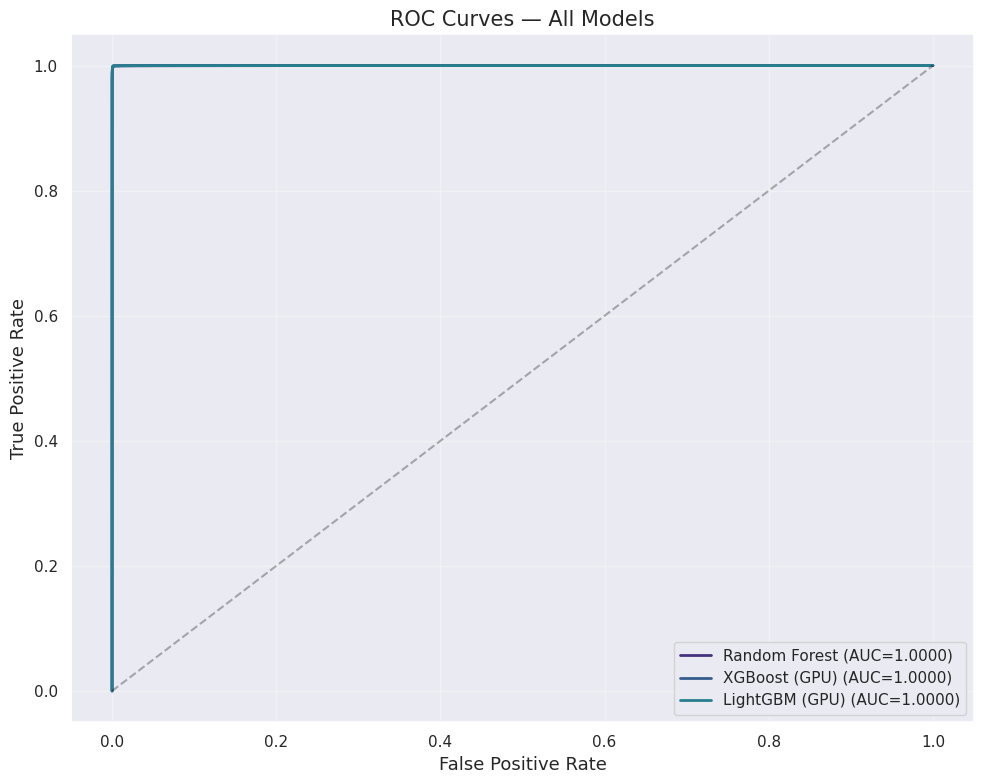

In [61]:
plt.figure(figsize=(10, 8))
for name, (_, y_prob) in models_eval.items():
    fpr, tpr, _ = roc_curve(y_b_test, y_prob)
    auc_val = roc_auc_score(y_b_test, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc_val:.4f})')

plt.plot([0,1], [0,1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curves — All Models', fontsize=15)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9.4 Confusion Matrices
### What this does
Plots confusion matrix heatmaps for all models.
### Why
Shows exact counts of TP, TN, FP, FN to understand error patterns.
### Expected output
Grid of confusion matrix heatmaps.

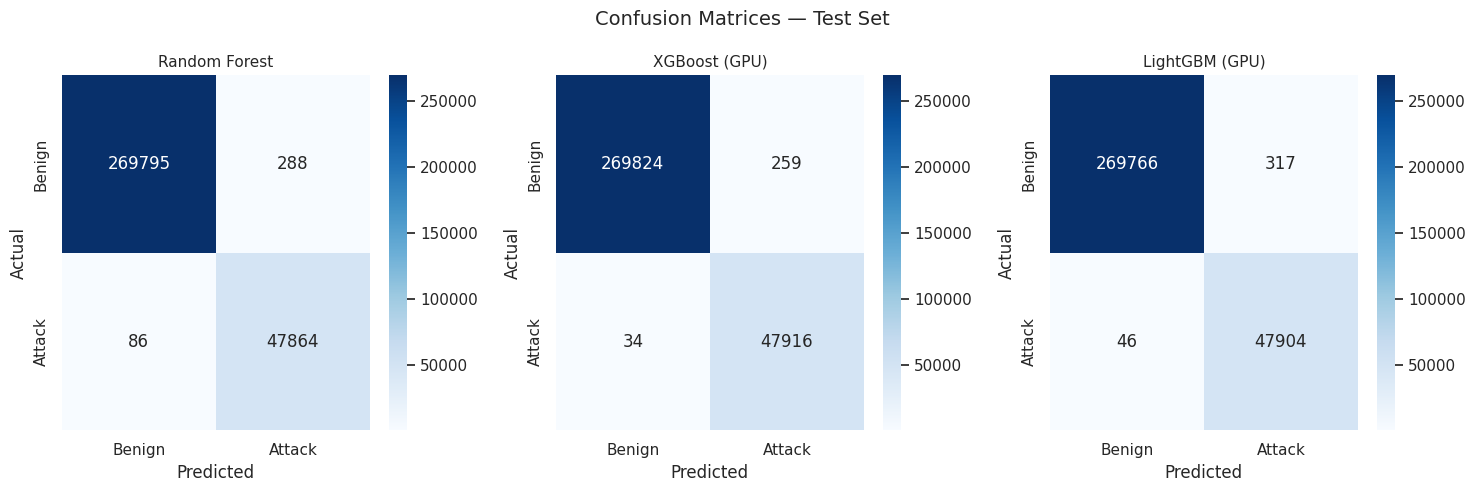

In [62]:
n_models = len(models_eval)
fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 5))
if n_models == 1:
    axes = [axes]

for ax, (name, (y_pred, _)) in zip(axes, models_eval.items()):
    cm = confusion_matrix(y_b_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Benign','Attack'], yticklabels=['Benign','Attack'])
    ax.set_title(name, fontsize=11)
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — Test Set', fontsize=14)
plt.tight_layout()
plt.show()

### 9.5 Multi-Class Evaluation (Best Model)
### What this does
Evaluates the best-performing model on multi-class attack classification.
### Why
Per-attack-type metrics reveal if specific attacks are harder to detect.
### Expected output
Per-class precision, recall, F1 for each attack type.

Training Stage 2 — XGBoost Multiclass Attack Classifier...
  Training samples : 230,806
  Attack classes   : 8
  Classes          : [np.str_('Bot'), np.str_('DDoS'), np.str_('DoS'), np.str_('FTP-Patator'), np.str_('PortScan'), np.str_('Rare Attack'), np.str_('SSH-Patator'), np.str_('Web Attack')]

[0]	val_atk-mlogloss:0.78340	val_atk-merror:0.42421
[50]	val_atk-mlogloss:0.04993	val_atk-merror:0.00060
[73]	val_atk-mlogloss:0.01723	val_atk-merror:0.00060

Training time: 2.2s

Stage 2 Isolated Report (on true attack samples only):
              precision    recall  f1-score   support

         Bot       1.00      0.99      1.00       205
        DDoS       1.00      1.00      1.00     18242
         DoS       1.00      1.00      1.00     27609
 FTP-Patator       1.00      1.00      1.00       845
    PortScan       0.99      0.98      0.98       278
 Rare Attack       0.83      0.71      0.77         7
 SSH-Patator       1.00      0.99      0.99       459
  Web Attack       0.98      1.00

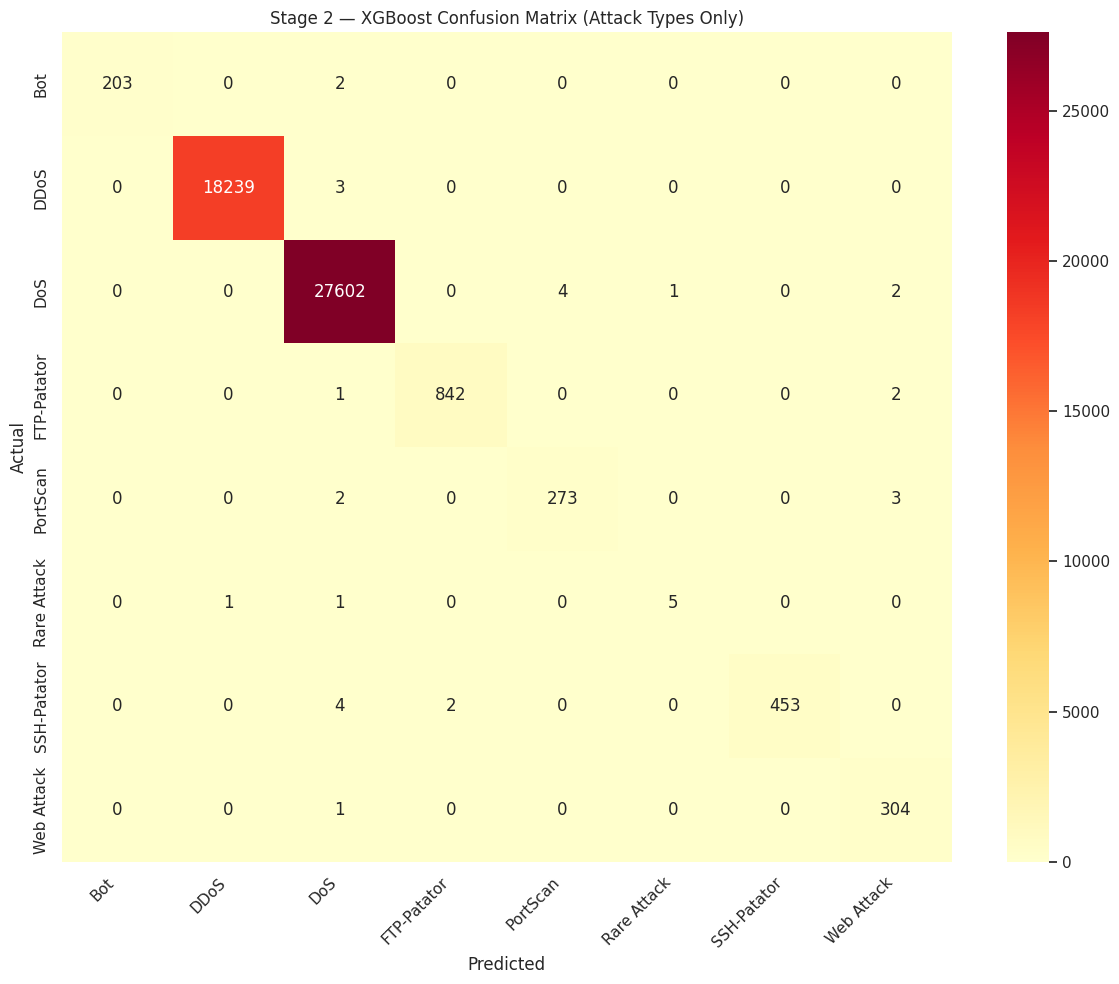

Stage 2 XGBoost model saved.


In [63]:
# ── 9.5 Stage 2: XGBoost Attack Classifier (Attack Classes Only) ─────────────
# XGBoost multi:softprob replaces Random Forest here.
# Reasons: (1) higher per-class F1 on rare attack types, (2) GPU-accelerated,
# (3) calibrated class probabilities for the agent confidence score.

import xgboost as xgb

print("Training Stage 2 — XGBoost Multiclass Attack Classifier...")
print(f"  Training samples : {X_train_s2.shape[0]:,}")
print(f"  Attack classes   : {len(le2.classes_)}")
print(f"  Classes          : {list(le2.classes_)}\n")

# Prepare XGBoost datasets
attack_mask_test = (y_b_test == 1)
X_test_atk       = X_test[attack_mask_test]
y_m_test_atk_names = le.inverse_transform(y_m_test[attack_mask_test])
y_m_test_s2      = le2.transform(y_m_test_atk_names)

dtrain_s2 = xgb.DMatrix(X_train_s2, label=y_m_train_s2)
dval_atk   = xgb.DMatrix(X_test_atk,  label=y_m_test_s2)

params_s2 = {
    'objective'        : 'multi:softprob',
    'num_class'        : len(le2.classes_),
    'eval_metric'      : ['mlogloss', 'merror'],
    'tree_method'      : 'hist',
    'device'           : 'cuda',
    'max_depth'        : 8,
    'learning_rate'    : 0.05,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'min_child_weight' : 5,
    'seed'             : 42,
}

t0 = time.time()
try:
    xgb_stage2 = xgb.train(
        params_s2, dtrain_s2,
        num_boost_round=400,
        evals=[(dval_atk, 'val_atk')],
        early_stopping_rounds=25,
        verbose_eval=50,
    )
except Exception as gpu_err:
    print(f"GPU failed ({gpu_err}), falling back to CPU...")
    params_s2['device'] = 'cpu'
    xgb_stage2 = xgb.train(
        params_s2, dtrain_s2,
        num_boost_round=400,
        evals=[(dval_atk, 'val_atk')],
        early_stopping_rounds=25,
        verbose_eval=50,
    )
print(f"\nTraining time: {time.time()-t0:.1f}s")

# ── Evaluate Stage 2 in isolation ────────────────────────────────────────────
prob_matrix_s2 = xgb_stage2.predict(dval_atk).reshape(-1, len(le2.classes_))
y_pred_s2_isolated = prob_matrix_s2.argmax(axis=1)

print("\nStage 2 Isolated Report (on true attack samples only):")
print(classification_report(
    y_m_test_s2, y_pred_s2_isolated,
    labels=np.arange(len(le2.classes_)),
    target_names=le2.classes_,
    zero_division=0
))

macro_f1_s2 = f1_score(y_m_test_s2, y_pred_s2_isolated,
                        average='macro', zero_division=0)
print(f"★ Stage 2 XGBoost Macro F1 (isolated): {macro_f1_s2:.4f}")

# Confusion matrix
plt.figure(figsize=(12, 10))
cm_s2 = confusion_matrix(y_m_test_s2, y_pred_s2_isolated,
                          labels=np.arange(len(le2.classes_)))
sns.heatmap(cm_s2, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=le2.classes_, yticklabels=le2.classes_)
plt.title('Stage 2 — XGBoost Confusion Matrix (Attack Types Only)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

xgb_stage2.save_model('/kaggle/working/xgb_stage2_attack_classifier.json')
print("Stage 2 XGBoost model saved.")


### 9.5c Stage 3 — Zero-Day Autoencoder

**What this does**
Trains a deep autoencoder exclusively on known attack samples. At inference, flows
with high reconstruction error are flagged as potential zero-day threats.

**Why**
XGBoost (Stage 2) always forces an unknown attack into a known class, often with low
confidence. The autoencoder provides an independent novelty signal: if it cannot
reconstruct the flow well, the flow does not match any known attack pattern.

**Threshold**
After training, the 95th-percentile reconstruction error over the validation attack
set becomes the zero-day threshold. 95% of known attacks fall below it; anything
above is flagged as a possible zero-day.


ZeroDayAutoencoder | input_dim=47 | params=31,679
Epoch 001/60 | Train: 0.642797 | Val: 0.090459
Epoch 010/60 | Train: 0.092983 | Val: 0.022457
Epoch 020/60 | Train: 0.077701 | Val: 0.016650
Epoch 030/60 | Train: 0.071565 | Val: 0.016768
Epoch 040/60 | Train: 0.068412 | Val: 0.014155
Epoch 050/60 | Train: 0.066359 | Val: 0.013046
Epoch 060/60 | Train: 0.066094 | Val: 0.012062

Best val reconstruction loss: 0.011587


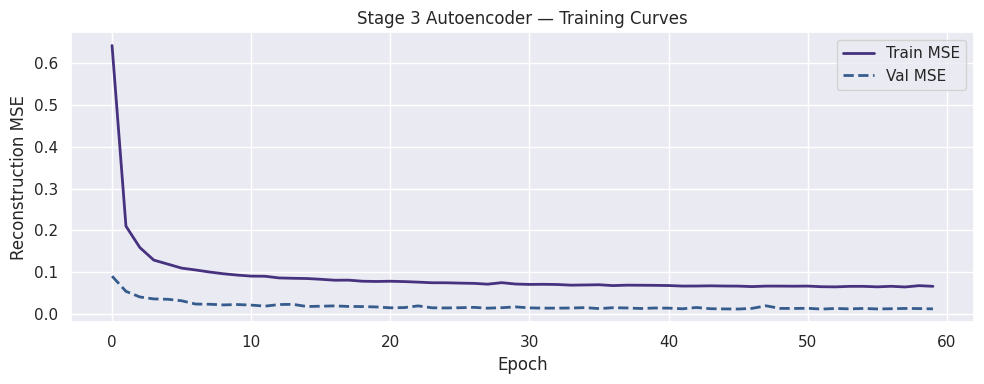


Zero-Day Threshold (95th pct of known attacks): 0.022869
  Known attacks below threshold : 95.0%
  Known attacks above threshold : 5.0%


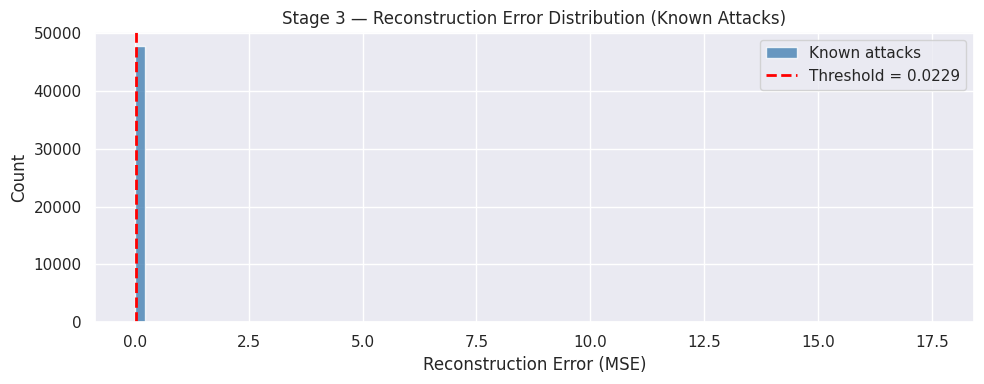

Threshold saved.

THREE-STAGE PIPELINE — End-to-End Evaluation

[ Stage 1 — LightGBM Binary Detection ]
  Optimal threshold (recall>=0.97): 0.9868
    Precision: 0.9999 | Recall: 0.9737
  Flagged Benign : 271,340 | Flagged Attack : 46,693
  Accuracy       : 0.9960
  Macro F1       : 0.9921
  ROC-AUC        : 1.0000

[ Stage 2 — XGBoost Attack Classification ]
  Flows sent to Stage 2 : 46,693
    DoS                         26753
    DDoS                        18192
    FTP-Patator                   814
    SSH-Patator                   418
    Web Attack                    270
    PortScan                      164
    Bot                            82

[ Stage 3 — Autoencoder Zero-Day Detection ]
  Flows assessed        : 46,693
  Confirmed known       : 44,571
  Flagged zero-day      : 2,122
  Zero-day rate         : 4.54%


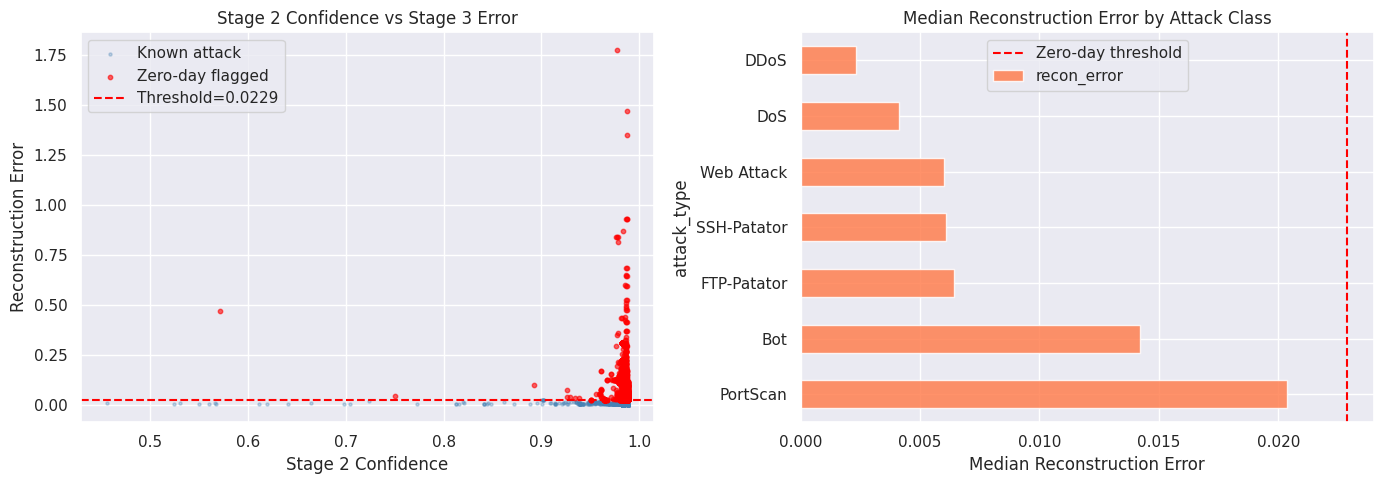


End-to-End Pipeline Report (zero-day flows excluded from report):
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    270081
         Bot       1.00      0.40      0.57       205
        DDoS       1.00      1.00      1.00     17973
         DoS       1.00      0.97      0.98     25838
 FTP-Patator       1.00      0.96      0.98       844
    PortScan       0.96      0.42      0.58       205
 Rare Attack       0.00      0.00      0.00         7
 SSH-Patator       1.00      0.91      0.95       459
  Web Attack       0.99      0.88      0.93       299

    accuracy                           1.00    315911
   macro avg       0.88      0.73      0.78    315911
weighted avg       1.00      1.00      1.00    315911

★ End-to-End Macro F1 : 0.7776
  Stage 2 Macro F1    : 0.9656  (attack types in isolation)
  Zero-day flags      : 2,122 flows

Error Breakdown:
  Stage 1 false negatives : 1,263
  Stage 1 false positives : 6
  Stage 2 wrong typ

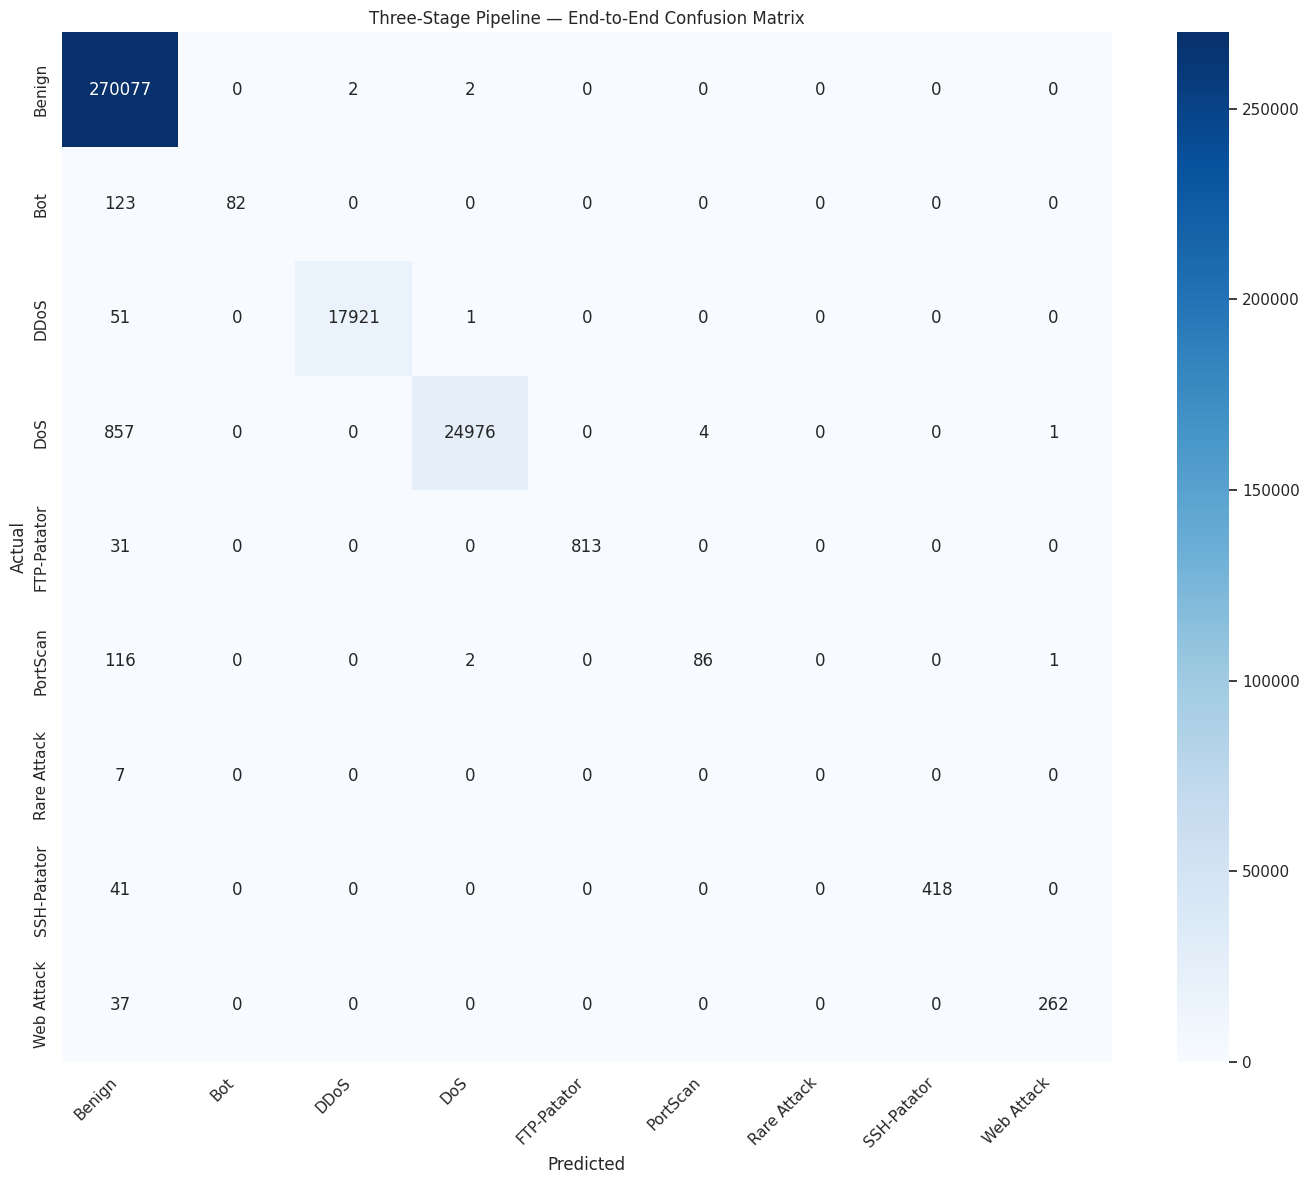

In [64]:
# ══════════════════════════════════════════════════════════════════════════════
# STAGE 3 — Zero-Day Autoencoder
# Train ONLY on known attack samples. Never on Benign.
# The model memorises the known-attack manifold; high reconstruction error
# at inference = the flow does not match any known attack = zero-day signal.
# ══════════════════════════════════════════════════════════════════════════════

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ── Architecture ──────────────────────────────────────────────────────────────
class ZeroDayAutoencoder(nn.Module):
    def __init__(self, input_dim: int, bottleneck: int = 16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Linear(64, bottleneck),
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, 64),  nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Linear(64, 128),         nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, input_dim),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def reconstruction_error(self, x: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            return torch.mean((x - self.forward(x)) ** 2, dim=1)


input_dim    = X_train_s2.shape[1]
autoencoder  = ZeroDayAutoencoder(input_dim=input_dim, bottleneck=16).to(DEVICE)
if torch.cuda.device_count() > 1:
    autoencoder = nn.DataParallel(autoencoder)

total_params = sum(p.numel() for p in autoencoder.parameters() if p.requires_grad)
print(f"ZeroDayAutoencoder | input_dim={input_dim} | params={total_params:,}")

# ── DataLoaders — attack-only ──────────────────────────────────────────────────
AE_BATCH  = 2048
AE_EPOCHS = 60
AE_LR     = 1e-3

X_train_s2_t = torch.tensor(X_train_s2, dtype=torch.float32)
X_test_atk_t = torch.tensor(X_test_atk,  dtype=torch.float32)

ae_train_loader = DataLoader(TensorDataset(X_train_s2_t), batch_size=AE_BATCH,
                              shuffle=True,  pin_memory=True, num_workers=2)
ae_val_loader   = DataLoader(TensorDataset(X_test_atk_t),  batch_size=AE_BATCH*2,
                              shuffle=False, pin_memory=True, num_workers=2)

# ── Training loop ─────────────────────────────────────────────────────────────
ae_criterion  = nn.MSELoss()
ae_optimizer  = optim.Adam(autoencoder.parameters(), lr=AE_LR, weight_decay=1e-5)
ae_scheduler  = optim.lr_scheduler.CosineAnnealingLR(ae_optimizer, T_max=AE_EPOCHS)

ae_train_losses, ae_val_losses = [], []
best_ae_val = float('inf')
ae_no_improve = 0

for epoch in range(AE_EPOCHS):
    autoencoder.train()
    epoch_loss = 0.0
    for (xb,) in ae_train_loader:
        xb = xb.to(DEVICE, non_blocking=True)
        ae_optimizer.zero_grad()
        loss = ae_criterion(autoencoder(xb), xb)
        loss.backward()
        ae_optimizer.step()
        epoch_loss += loss.item() * len(xb)
    train_loss = epoch_loss / len(X_train_s2_t)
    ae_train_losses.append(train_loss)

    autoencoder.eval()
    val_loss = sum(ae_criterion(autoencoder(xb.to(DEVICE)), xb.to(DEVICE)).item() * len(xb)
                   for (xb,) in ae_val_loader) / len(X_test_atk_t)
    ae_val_losses.append(val_loss)
    ae_scheduler.step()

    if val_loss < best_ae_val:
        best_ae_val = val_loss
        torch.save(autoencoder.state_dict(), '/kaggle/working/autoencoder.pt')
        ae_no_improve = 0
    else:
        ae_no_improve += 1
        if ae_no_improve >= 10:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:03d}/{AE_EPOCHS} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

print(f"\nBest val reconstruction loss: {best_ae_val:.6f}")

# Training curves
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ae_train_losses, label='Train MSE', linewidth=2)
ax.plot(ae_val_losses,   label='Val MSE',   linewidth=2, linestyle='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Reconstruction MSE')
ax.set_title('Stage 3 Autoencoder — Training Curves')
ax.legend(); plt.tight_layout(); plt.show()

# ── Threshold calibration ─────────────────────────────────────────────────────
autoencoder.load_state_dict(torch.load('/kaggle/working/autoencoder.pt'))
autoencoder.eval()
ae_core = autoencoder.module if hasattr(autoencoder, 'module') else autoencoder

errors_val = ae_core.reconstruction_error(X_test_atk_t.to(DEVICE)).cpu().numpy()
ZERO_DAY_THRESHOLD = float(np.percentile(errors_val, 95))
print(f"\nZero-Day Threshold (95th pct of known attacks): {ZERO_DAY_THRESHOLD:.6f}")
print(f"  Known attacks below threshold : {(errors_val <= ZERO_DAY_THRESHOLD).mean()*100:.1f}%")
print(f"  Known attacks above threshold : {(errors_val >  ZERO_DAY_THRESHOLD).mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(errors_val, bins=80, color='steelblue', alpha=0.8, label='Known attacks')
ax.axvline(ZERO_DAY_THRESHOLD, color='red', linewidth=2, linestyle='--',
           label=f'Threshold = {ZERO_DAY_THRESHOLD:.4f}')
ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Count')
ax.set_title('Stage 3 — Reconstruction Error Distribution (Known Attacks)')
ax.legend(); plt.tight_layout(); plt.show()

import pickle
with open('/kaggle/working/zero_day_threshold.pkl', 'wb') as f:
    pickle.dump(ZERO_DAY_THRESHOLD, f)
print("Threshold saved.")


# ══════════════════════════════════════════════════════════════════════════════
# THREE-STAGE PIPELINE — End-to-End Evaluation
# Stage 1: LightGBM  binary gate
# Stage 2: XGBoost   multiclass attack type
# Stage 3: Autoencoder  zero-day / novelty
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("THREE-STAGE PIPELINE — End-to-End Evaluation")
print("=" * 65)

# ── Stage 1: LightGBM ─────────────────────────────────────────────────────────
print("\n[ Stage 1 — LightGBM Binary Detection ]")
y_prob_s1 = lgb_model.predict(X_test).astype(np.float32)

from sklearn.metrics import precision_recall_curve
precisions_s1, recalls_s1, thresholds_s1 = precision_recall_curve(y_b_test, y_prob_s1)
high_recall_idx = np.where(recalls_s1 >= 0.97)[0]
if len(high_recall_idx) > 0:
    best_idx = high_recall_idx[np.argmax(precisions_s1[high_recall_idx])]
    OPTIMAL_S1_THRESHOLD = float(thresholds_s1[best_idx])
    print(f"  Optimal threshold (recall>=0.97): {OPTIMAL_S1_THRESHOLD:.4f}")
    print(f"    Precision: {precisions_s1[best_idx]:.4f} | Recall: {recalls_s1[best_idx]:.4f}")
else:
    OPTIMAL_S1_THRESHOLD = 0.30
    print(f"  Using default threshold: {OPTIMAL_S1_THRESHOLD}")

y_pred_s1 = (y_prob_s1 >= OPTIMAL_S1_THRESHOLD).astype(int)
s1_total   = len(y_pred_s1)
print(f"  Flagged Benign : {(y_pred_s1==0).sum():,} | Flagged Attack : {(y_pred_s1==1).sum():,}")
print(f"  Accuracy       : {accuracy_score(y_b_test, y_pred_s1):.4f}")
print(f"  Macro F1       : {f1_score(y_b_test, y_pred_s1, average='macro'):.4f}")
print(f"  ROC-AUC        : {roc_auc_score(y_b_test, y_prob_s1):.4f}")

# ── Stage 2: XGBoost ──────────────────────────────────────────────────────────
print("\n[ Stage 2 — XGBoost Attack Classification ]")
attack_flagged_mask = (y_pred_s1 == 1)
X_test_flagged      = X_test[attack_flagged_mask]

y_pred_s2_names = np.full(attack_flagged_mask.sum(), 'Unknown', dtype=object)
s2_confidences  = np.zeros(attack_flagged_mask.sum(), dtype=np.float32)

if len(X_test_flagged) > 0:
    d_flagged   = xgb.DMatrix(X_test_flagged)
    prob_mat    = xgb_stage2.predict(d_flagged).reshape(-1, len(le2.classes_))
    s2_idx      = prob_mat.argmax(axis=1)
    y_pred_s2_names = le2.inverse_transform(s2_idx)
    s2_confidences  = prob_mat.max(axis=1)

print(f"  Flows sent to Stage 2 : {len(X_test_flagged):,}")
for cls, cnt in Counter(y_pred_s2_names).most_common():
    print(f"    {cls:<25} {cnt:>7}")

# ── Stage 3: Autoencoder ──────────────────────────────────────────────────────
print("\n[ Stage 3 — Autoencoder Zero-Day Detection ]")
X_flagged_t  = torch.tensor(X_test_flagged, dtype=torch.float32).to(DEVICE)
recon_errors = ae_core.reconstruction_error(X_flagged_t).cpu().numpy()
zero_day_flags = (recon_errors > ZERO_DAY_THRESHOLD)

print(f"  Flows assessed        : {len(X_test_flagged):,}")
print(f"  Confirmed known       : {(~zero_day_flags).sum():,}")
print(f"  Flagged zero-day      : {zero_day_flags.sum():,}")
print(f"  Zero-day rate         : {zero_day_flags.mean()*100:.2f}%")

# Scatter: S2 confidence vs S3 reconstruction error
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(s2_confidences[~zero_day_flags], recon_errors[~zero_day_flags],
                alpha=0.3, s=5, color='steelblue', label='Known attack')
axes[0].scatter(s2_confidences[zero_day_flags], recon_errors[zero_day_flags],
                alpha=0.6, s=10, color='red', label='Zero-day flagged')
axes[0].axhline(ZERO_DAY_THRESHOLD, color='red', linestyle='--', linewidth=1.5,
                label=f'Threshold={ZERO_DAY_THRESHOLD:.4f}')
axes[0].set_xlabel('Stage 2 Confidence'); axes[0].set_ylabel('Reconstruction Error')
axes[0].set_title('Stage 2 Confidence vs Stage 3 Error'); axes[0].legend()

import pandas as pd
err_df = pd.DataFrame({'attack_type': y_pred_s2_names, 'recon_error': recon_errors})
err_by_class = err_df.groupby('attack_type')['recon_error'].median().sort_values(ascending=False)
err_by_class.plot(kind='barh', ax=axes[1], color='coral', alpha=0.85)
axes[1].axvline(ZERO_DAY_THRESHOLD, color='red', linestyle='--', linewidth=1.5,
                label='Zero-day threshold')
axes[1].set_xlabel('Median Reconstruction Error')
axes[1].set_title('Median Reconstruction Error by Attack Class')
axes[1].legend()
plt.tight_layout(); plt.show()

# ── Unified final labels ───────────────────────────────────────────────────────
y_pred_final = np.where(y_pred_s1 == 0, 'Benign', 'TBD').astype(object)
y_pred_final[attack_flagged_mask] = y_pred_s2_names

zero_day_mask_full = np.zeros(s1_total, dtype=bool)
zero_day_mask_full[np.where(attack_flagged_mask)[0][zero_day_flags]] = True
y_pred_final[zero_day_mask_full] = 'ZERO_DAY'

y_true_final     = le.inverse_transform(y_m_test)
all_classes_e2e  = ['Benign'] + sorted(attack_class_names)
mask_excl_zd     = ~zero_day_mask_full

print("\nEnd-to-End Pipeline Report (zero-day flows excluded from report):")
print(classification_report(y_true_final[mask_excl_zd], y_pred_final[mask_excl_zd],
                             labels=all_classes_e2e, zero_division=0))

e2e_macro_f1 = f1_score(y_true_final[mask_excl_zd], y_pred_final[mask_excl_zd],
                          labels=all_classes_e2e, average='macro', zero_division=0)
print(f"★ End-to-End Macro F1 : {e2e_macro_f1:.4f}")
print(f"  Stage 2 Macro F1    : {macro_f1_s2:.4f}  (attack types in isolation)")
print(f"  Zero-day flags      : {zero_day_mask_full.sum():,} flows")

s1_fn = ((y_b_test == 1) & (y_pred_s1 == 0)).sum()
s1_fp = ((y_b_test == 0) & (y_pred_s1 == 1)).sum()
total_err = (y_true_final[mask_excl_zd] != y_pred_final[mask_excl_zd]).sum()
print(f"\nError Breakdown:")
print(f"  Stage 1 false negatives : {s1_fn:,}")
print(f"  Stage 1 false positives : {s1_fp:,}")
print(f"  Stage 2 wrong type      : {max(0, total_err - s1_fn - s1_fp):,}")

# End-to-end confusion matrix
plt.figure(figsize=(14, 12))
cm_e2e = confusion_matrix(y_true_final[mask_excl_zd], y_pred_final[mask_excl_zd],
                           labels=all_classes_e2e)
sns.heatmap(cm_e2e, annot=True, fmt='d', cmap='Blues',
            xticklabels=all_classes_e2e, yticklabels=all_classes_e2e)
plt.title('Three-Stage Pipeline — End-to-End Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


### 9.6 Class Imbalance Impact & Three-Stage Pipeline Discussion

**Why the three-stage architecture handles imbalance better than a single model**

A flat multiclass classifier trained on CIC-IDS2017 sees ~83% BENIGN samples.
It optimises for overall accuracy, which means rare attack classes (Bot: 1,966 samples,
Infiltration: 36 samples after grouping) are systematically under-learned.

The three-stage pipeline addresses this at each level:

| Stage | Imbalance strategy |
|---|---|
| Stage 1 | `scale_pos_weight` in LightGBM + optimised threshold (recall ≥ 0.97) |
| Stage 2 | Trained **only on attack samples** — BENIGN never seen, imbalance reduced |
| Stage 3 | Unsupervised — reconstruction error has no class label dependency |

**Reading the confusion matrix**
Rows = true class, columns = predicted class.
Off-diagonal cells in the attack rows = Stage 2 misclassifications (wrong type).
Off-diagonal cells in the Benign row = Stage 1 false positives.
Off-diagonal cells in the Benign column = Stage 1 false negatives (most dangerous).

**Zero-day rate interpretation**
A zero-day rate of 1-5% on CIC-IDS2017 is expected — the threshold is set at the
95th percentile of known-attack errors, so by design 5% of known attacks are
flagged. In production on genuinely new traffic, the rate will differ.
Monitor it over time: a sustained spike indicates a new attack pattern.


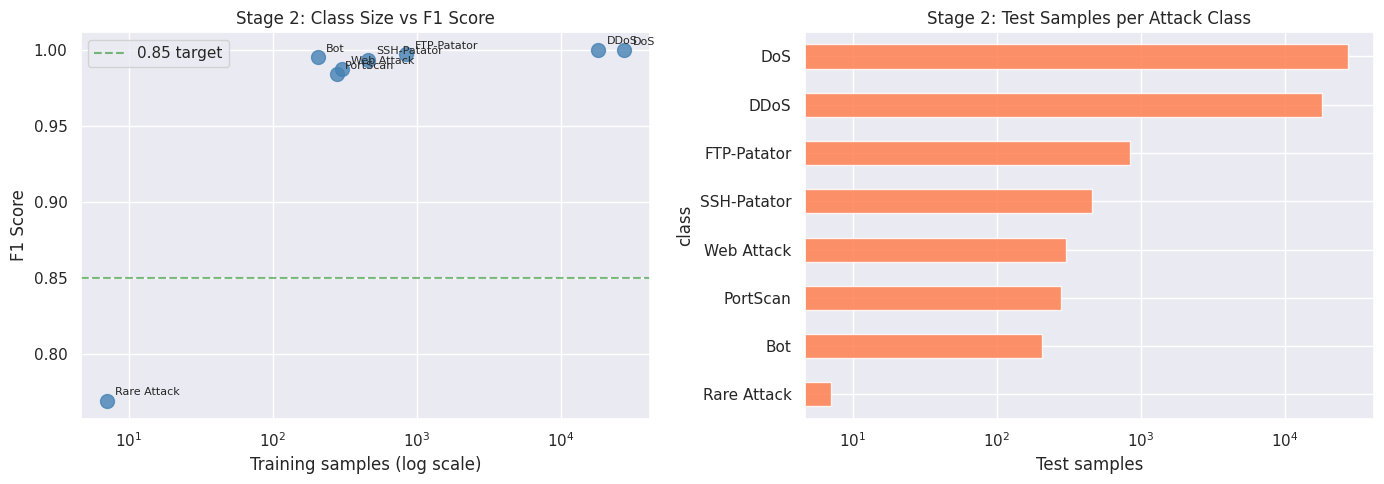


Class Analysis Summary:
      class       f1  support
Rare Attack 0.769231        7
   PortScan 0.983784      278
 Web Attack 0.987013      305
SSH-Patator 0.993421      459
        Bot 0.995098      205
FTP-Patator 0.997040      845
        DoS 0.999620    27609
       DDoS 0.999890    18242


In [65]:
# ── 9.6 Class size vs F1 analysis (Stage 2 XGBoost) ─────────────────────────
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

# Per-class F1 from Stage 2
_, _, class_f1_vals, class_support = precision_recall_fscore_support(
    y_m_test_s2, y_pred_s2_isolated,
    labels=np.arange(len(le2.classes_)),
    zero_division=0
)

class_analysis = pd.DataFrame({
    'class'    : le2.classes_,
    'f1'       : class_f1_vals,
    'support'  : class_support,
})
class_analysis = class_analysis.sort_values('support')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: F1 vs class size scatter
axes[0].scatter(class_analysis['support'], class_analysis['f1'],
                s=100, color='steelblue', alpha=0.8, zorder=3)
for _, row in class_analysis.iterrows():
    axes[0].annotate(row['class'], (row['support'], row['f1']),
                     textcoords='offset points', xytext=(6, 4), fontsize=8)
axes[0].axhline(0.85, color='green', linestyle='--', alpha=0.5, label='0.85 target')
axes[0].set_xscale('log')
axes[0].set_xlabel('Training samples (log scale)')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('Stage 2: Class Size vs F1 Score')
axes[0].legend()

# Right: support bar
class_analysis.set_index('class')['support'].sort_values(ascending=True).plot(
    kind='barh', ax=axes[1], color='coral', alpha=0.85)
axes[1].set_xlabel('Test samples')
axes[1].set_title('Stage 2: Test Samples per Attack Class')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

print("\nClass Analysis Summary:")
print(class_analysis.sort_values('f1').to_string(index=False))


## 10. End-to-End Detection Pipeline
### What this does
Builds a reusable `AnomalyDetector` class and runs a **production simulation** on the
held-out 5% inference set — data the models have never seen.
### Why
The inference set was saved in Cell 4.5 specifically for this simulation. It tests the
full cascaded pipeline (binary detection → attack attribution) on realistic unseen traffic.
### Expected output
Binary metrics on inference set; attack type breakdown; per-flow sample predictions.

In [66]:
# ══════════════════════════════════════════════════════════════════════════════
# 10. Three-Stage Production Pipeline
# ══════════════════════════════════════════════════════════════════════════════

import torch, pickle, joblib, os
import numpy as np, pandas as pd
import lightgbm as lgb
import xgboost as xgb
import torch.nn as nn


class ZeroDayAutoencoder(nn.Module):
    """Must match the architecture used during training."""
    def __init__(self, input_dim: int, bottleneck: int = 16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Linear(64, bottleneck),
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, 64),  nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Linear(64, 128),         nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, input_dim),
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))
    def reconstruction_error(self, x):
        with torch.no_grad():
            return torch.mean((x - self.forward(x)) ** 2, dim=1)


class ThreeStagePipeline:
    """
    Full three-stage network intrusion detection pipeline.

    Stage 1 — LightGBM      : Binary gate (BENIGN / ATTACK)
    Stage 2 — XGBoost       : Multi-class attack type classification
    Stage 3 — Autoencoder   : Zero-day / novelty detection

    Output per flow:
    {
        verdict            : "BENIGN" | "ATTACK" | "ZERO_DAY"
        attack_probability : float   (Stage 1 raw score)
        attack_type        : str     (Stage 2 class name, or "BENIGN" / "ZERO_DAY")
        s2_confidence      : float   (Stage 2 max class prob)
        reconstruction_error: float  (Stage 3 MSE)
        zero_day_flag      : bool
    }
    """

    def __init__(self, model_path: str = '/kaggle/working/',
                 s1_threshold: float = 0.30,
                 device: str = None):

        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.s1_threshold = s1_threshold

        # ── Preprocessing artefacts ──────────────────────────────────────────
        self.scaler       = joblib.load(os.path.join(model_path, 'scaler.pkl'))
        self.feature_cols = joblib.load(os.path.join(model_path, 'feature_cols_final.pkl'))
        self.le           = joblib.load(os.path.join(model_path, 'label_encoder.pkl'))
        self.le2          = joblib.load(os.path.join(model_path, 'label_encoder_stage2.pkl'))

        # ── Stage 1: LightGBM binary ─────────────────────────────────────────
        self.lgb_model = lgb.Booster(
            model_file=os.path.join(model_path, 'lightgbm_model.txt'))  # Stage 1

        # ── Stage 2: XGBoost multiclass ──────────────────────────────────────
        self.xgb_stage2 = xgb.Booster()
        self.xgb_stage2.load_model(
            os.path.join(model_path, 'xgb_stage2_attack_classifier.json'))

        # ── Stage 3: Autoencoder ──────────────────────────────────────────────
        input_dim = len(self.feature_cols)
        self.autoencoder = ZeroDayAutoencoder(input_dim=input_dim).to(self.device)
        state = torch.load(os.path.join(model_path, 'autoencoder.pt'),
                           map_location=self.device)
        # Handle DataParallel-saved weights
        if any(k.startswith('module.') for k in state.keys()):
            state = {k.replace('module.', ''): v for k, v in state.items()}
        self.autoencoder.load_state_dict(state)
        self.autoencoder.eval()

        with open(os.path.join(model_path, 'zero_day_threshold.pkl'), 'rb') as f:
            self.zero_day_threshold = pickle.load(f)

        print(f"ThreeStagePipeline loaded")
        print(f"  Features           : {len(self.feature_cols)}")
        print(f"  Attack classes     : {list(self.le2.classes_)}")
        print(f"  S1 threshold       : {self.s1_threshold}")
        print(f"  Zero-day threshold : {self.zero_day_threshold:.6f}")
        print(f"  Device             : {self.device}")

    # ── Preprocessing ─────────────────────────────────────────────────────────
    def _preprocess(self, df_raw: pd.DataFrame) -> np.ndarray:
        df = df_raw.copy()
        df.columns = df.columns.str.strip()
        df.replace([np.inf, -np.inf], np.nan, inplace=True)
        for c in self.feature_cols:
            if c not in df.columns:
                df[c] = 0
        X = df[self.feature_cols].fillna(0).values.astype(np.float32)
        return self.scaler.transform(X)

    # ── Public predict method ─────────────────────────────────────────────────
    def predict(self, df_raw: pd.DataFrame) -> pd.DataFrame:
        X = self._preprocess(df_raw)
        n = len(X)
        results = pd.DataFrame({
            'verdict'             : ['BENIGN'] * n,
            'attack_probability'  : np.zeros(n, dtype=np.float32),
            'attack_type'         : ['BENIGN'] * n,
            's2_confidence'       : np.zeros(n, dtype=np.float32),
            'reconstruction_error': np.zeros(n, dtype=np.float32),
            'zero_day_flag'       : [False] * n,
        })

        # ── Stage 1 ───────────────────────────────────────────────────────────
        s1_probs = self.lgb_model.predict(X).astype(np.float32)
        results['attack_probability'] = s1_probs
        attack_mask = s1_probs >= self.s1_threshold
        results.loc[attack_mask, 'verdict'] = 'ATTACK'

        if not attack_mask.any():
            return results

        # ── Stage 2 ───────────────────────────────────────────────────────────
        X_atk      = X[attack_mask]
        d_atk      = xgb.DMatrix(X_atk)
        prob_matrix = self.xgb_stage2.predict(d_atk).reshape(-1, len(self.le2.classes_))
        s2_idx     = prob_matrix.argmax(axis=1)
        s2_names   = self.le2.inverse_transform(s2_idx)
        s2_conf    = prob_matrix.max(axis=1)

        results.loc[attack_mask, 'attack_type']   = s2_names
        results.loc[attack_mask, 's2_confidence']  = s2_conf

        # ── Stage 3 ───────────────────────────────────────────────────────────
        X_atk_t     = torch.tensor(X_atk, dtype=torch.float32).to(self.device)
        recon_errors = self.autoencoder.reconstruction_error(X_atk_t).cpu().numpy()
        zero_day     = recon_errors > self.zero_day_threshold

        atk_indices = np.where(attack_mask)[0]
        results.loc[attack_mask, 'reconstruction_error'] = recon_errors
        results.loc[attack_mask, 'zero_day_flag']         = zero_day

        # Zero-day flows override Stage 2 label
        zd_global_idx = atk_indices[zero_day]
        results.loc[zd_global_idx, 'verdict']     = 'ZERO_DAY'
        results.loc[zd_global_idx, 'attack_type'] = 'ZERO_DAY'

        return results


# ══════════════════════════════════════════════════════════════════════════════
# Production Simulation on held-out inference set
# ══════════════════════════════════════════════════════════════════════════════
pipeline = ThreeStagePipeline(model_path='/kaggle/working/')

infer_df       = pd.read_parquet('/kaggle/working/inference_set.parquet')
y_b_true_infer = infer_df['label_binary'].values.astype(int)
X_infer_raw    = infer_df[pipeline.feature_cols]

print(f"=== Production Simulation on {len(infer_df):,} Unseen Flows ===")
print(f"Ground truth — BENIGN: {(y_b_true_infer==0).sum():,} | ATTACK: {(y_b_true_infer==1).sum():,}")

import time
t0  = time.time()
out = pipeline.predict(X_infer_raw)
elapsed = time.time() - t0

print(f"Throughput: {elapsed*1000/len(infer_df):.3f} ms/flow ")
print(f"           ({int(len(infer_df)/elapsed):,} flows/sec)")

# ── Summary ───────────────────────────────────────────────────────────────────
print("--- Verdict Distribution ---")
print(out['verdict'].value_counts().to_string())

print("--- Stage 2 Attack Types (ATTACK flows only) ---")
atk_out = out[out['verdict'] == 'ATTACK']
print(atk_out['attack_type'].value_counts().to_string())

print(f"--- Stage 3 Zero-Day Summary ---")
print(f"  Zero-day flows flagged : {out['zero_day_flag'].sum():,}")
print(f"  Zero-day rate          : {out['zero_day_flag'].mean()*100:.2f}%")

# Binary metrics (ZERO_DAY counts as ATTACK for S1 evaluation)
preds_binary = (out['verdict'] != 'BENIGN').astype(int)
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
print("--- Binary Detection Metrics (inference set) ---")
print(f"  Accuracy : {accuracy_score(y_b_true_infer, preds_binary):.4f}")
print(f"  Macro F1 : {f1_score(y_b_true_infer, preds_binary, average='macro'):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_b_true_infer, out['attack_probability']):.4f}")

# Sample predictions
print("--- Sample Predictions (first 12 flows) ---")
sample = out.head(12).copy()
sample['true'] = ['ATTACK' if y else 'BENIGN' for y in y_b_true_infer[:12]]
sample['ok']   = sample['verdict'].apply(lambda v: 'BENIGN' if v == 'BENIGN' else 'ATTACK') == sample['true']
print(sample[['verdict', 'attack_probability', 'attack_type',
              's2_confidence', 'reconstruction_error', 'zero_day_flag',
              'true', 'ok']].to_string(index=False))


ThreeStagePipeline loaded
  Features           : 47
  Attack classes     : [np.str_('Bot'), np.str_('DDoS'), np.str_('DoS'), np.str_('FTP-Patator'), np.str_('PortScan'), np.str_('Rare Attack'), np.str_('SSH-Patator'), np.str_('Web Attack')]
  S1 threshold       : 0.3
  Zero-day threshold : 0.022869
  Device             : cuda
=== Production Simulation on 111,591 Unseen Flows ===
Ground truth — BENIGN: 94,766 | ATTACK: 16,825
Throughput: 0.004 ms/flow 
           (231,751 flows/sec)
--- Verdict Distribution ---
verdict
BENIGN      94592
ATTACK      16154
ZERO_DAY      845
--- Stage 2 Attack Types (ATTACK flows only) ---
attack_type
DoS            9130
DDoS           6324
FTP-Patator     295
SSH-Patator     150
Bot             105
Web Attack       96
PortScan         54
--- Stage 3 Zero-Day Summary ---
  Zero-day flows flagged : 845
  Zero-day rate          : 0.76%
--- Binary Detection Metrics (inference set) ---
  Accuracy : 0.9983
  Macro F1 : 0.9967
  ROC-AUC  : 1.0000
--- Sample Pred

## 11. Results Visualization Summary
### What this does
Creates a comprehensive visual summary of all model results.
### Why
Final dashboard for stakeholder communication and model selection.
### Expected output
Combined figure with key metrics.

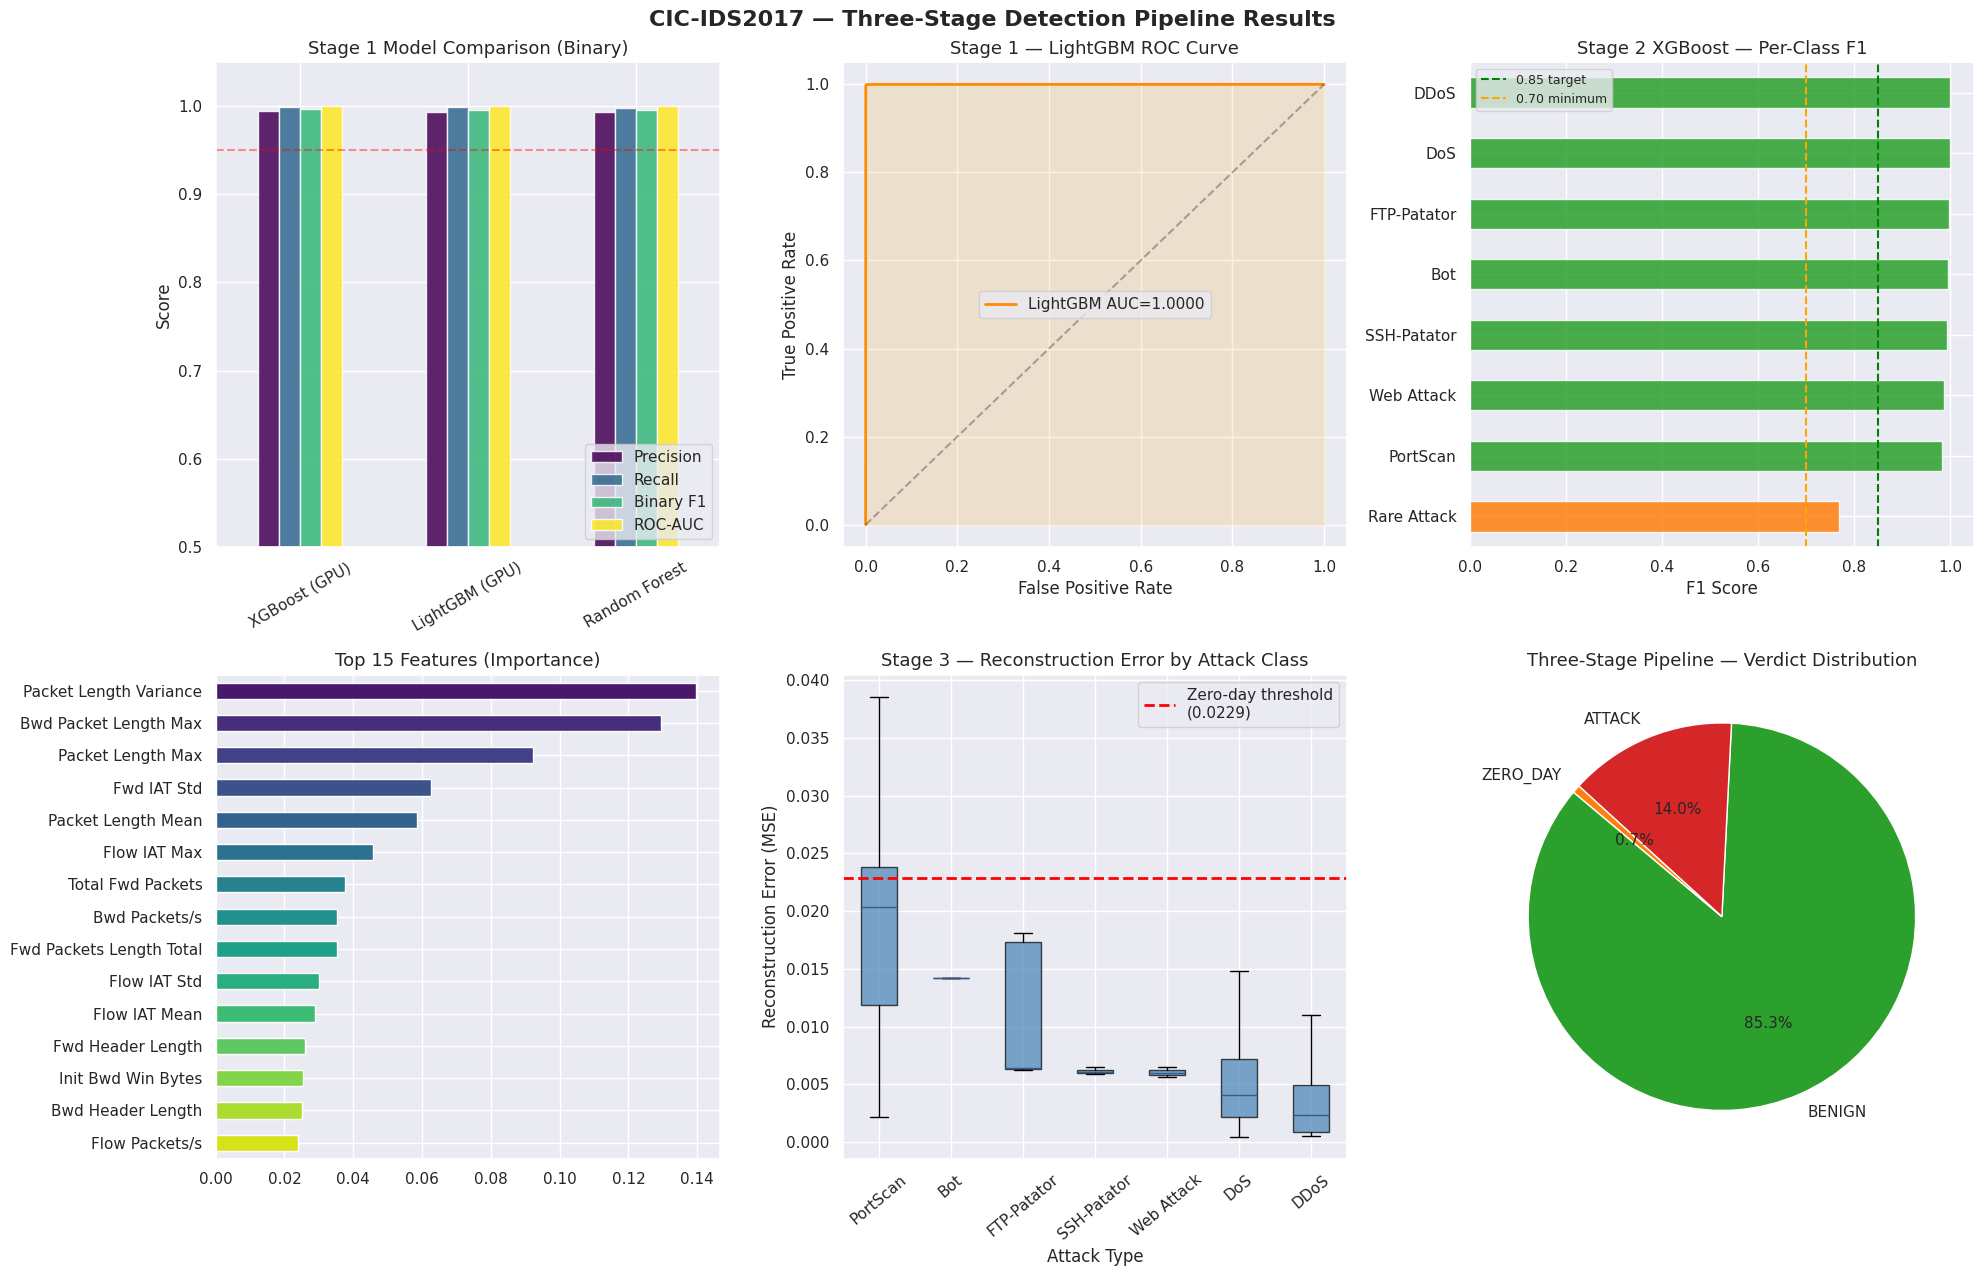

Dashboard saved to /kaggle/working/results_dashboard.png


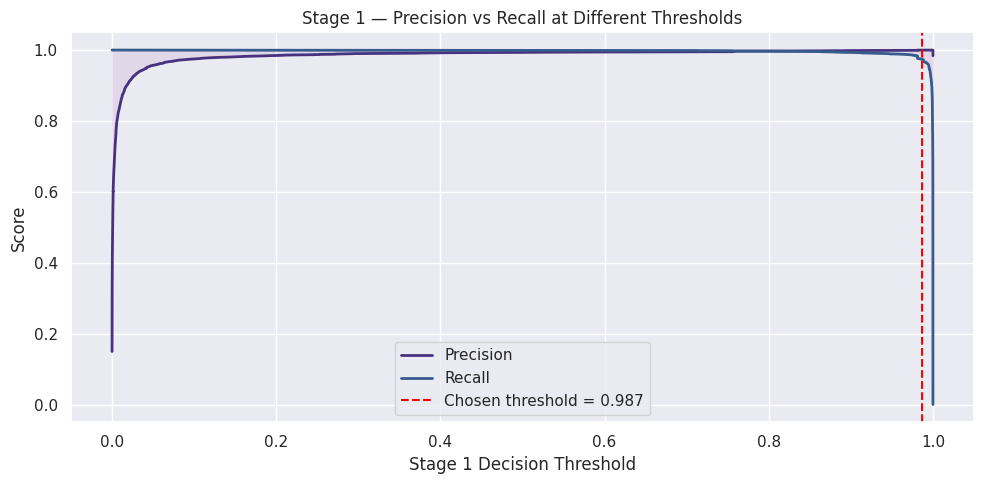

Threshold analysis saved.


In [69]:
# ── 11. Results Visualization Summary ───────────────────────────────────────
# Comprehensive dashboard: model comparison, ROC, feature importance,
# class distribution, AND new Stage 3 reconstruction error analysis.

import pandas as pd

# Regenerate Stage 1 predictions on test set for dashboard
y_prob_lgb = lgb_model.predict(X_test)
y_pred_lgb = (y_prob_lgb > OPTIMAL_S1_THRESHOLD).astype(int)

# ── Panel 1+2: model comparison + best ROC (existing) ─────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 13))

# 1. Model comparison bar chart
results_df[['Precision','Recall','Binary F1','ROC-AUC']].plot(
    kind='bar', ax=axes[0,0], colormap='viridis', alpha=0.85)
axes[0,0].set_title('Stage 1 Model Comparison (Binary)', fontsize=13)
axes[0,0].set_ylabel('Score')
axes[0,0].set_ylim(0.5, 1.05)
axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].legend(loc='lower right')
axes[0,0].axhline(0.95, color='red', linestyle='--', alpha=0.4, label='0.95 bar')

# 2. LightGBM ROC (Stage 1)
fpr_lgb, tpr_lgb, _ = roc_curve(y_b_test, y_prob_lgb)
auc_lgb = roc_auc_score(y_b_test, y_prob_lgb)
axes[0,1].plot(fpr_lgb, tpr_lgb, linewidth=2, color='darkorange',
               label=f'LightGBM AUC={auc_lgb:.4f}')
axes[0,1].fill_between(fpr_lgb, tpr_lgb, alpha=0.15, color='orange')
axes[0,1].plot([0,1],[0,1],'k--',alpha=0.3)
axes[0,1].set_title('Stage 1 — LightGBM ROC Curve', fontsize=13)
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].legend()

# 3. Stage 2 XGBoost — per-class F1
from sklearn.metrics import precision_recall_fscore_support
class_prec, class_rec, class_f1, class_supp = precision_recall_fscore_support(
    y_m_test_s2, y_pred_s2_isolated,
    labels=np.arange(len(le2.classes_)),
    zero_division=0
)
class_f1_df = pd.Series(class_f1, index=le2.classes_).sort_values()
colors_s2 = ['#d62728' if v < 0.7 else '#ff7f0e' if v < 0.85 else '#2ca02c'
              for v in class_f1_df.values]
class_f1_df.plot(kind='barh', ax=axes[0,2], color=colors_s2, alpha=0.85)
axes[0,2].axvline(0.85, color='green', linestyle='--', linewidth=1.5,
                   label='0.85 target')
axes[0,2].axvline(0.70, color='orange', linestyle='--', linewidth=1.5,
                   label='0.70 minimum')
axes[0,2].set_title('Stage 2 XGBoost — Per-Class F1', fontsize=13)
axes[0,2].set_xlabel('F1 Score')
axes[0,2].legend(fontsize=9)

# 4. Top 15 features (from quick RF in cell 5)
importances[:15].plot(kind='barh', ax=axes[1,0],
                       color=sns.color_palette('viridis', 15))
axes[1,0].set_title('Top 15 Features (Importance)', fontsize=13)
axes[1,0].invert_yaxis()

# 5. Stage 3 — reconstruction error distribution by class
err_df_plot = pd.DataFrame({
    'attack_type'  : y_pred_s2_names,
    'recon_error'  : recon_errors,
    'zero_day'     : zero_day_flags,
})
class_order = (err_df_plot.groupby('attack_type')['recon_error']
               .median().sort_values(ascending=False).index)
bp_data = [err_df_plot[err_df_plot['attack_type']==c]['recon_error'].values
           for c in class_order]
bp = axes[1,1].boxplot(bp_data, labels=class_order, patch_artist=True,
                        showfliers=False, vert=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
axes[1,1].axhline(ZERO_DAY_THRESHOLD, color='red', linestyle='--', linewidth=2,
                   label=f'Zero-day threshold\n({ZERO_DAY_THRESHOLD:.4f})')
axes[1,1].set_title('Stage 3 — Reconstruction Error by Attack Class', fontsize=13)
axes[1,1].set_xlabel('Attack Type')
axes[1,1].set_ylabel('Reconstruction Error (MSE)')
axes[1,1].tick_params(axis='x', rotation=40)
axes[1,1].legend()

# 6. Three-stage pipeline verdict distribution (pie)
verdict_counts = pd.Series({
    'BENIGN'   : (y_pred_final == 'Benign').sum(),
    'ATTACK'   : ((y_pred_final != 'Benign') & (y_pred_final != 'ZERO_DAY')).sum(),
    'ZERO_DAY' : (y_pred_final == 'ZERO_DAY').sum(),
})
colors_pie = ['#2ca02c', '#d62728', '#ff7f0e']
axes[1,2].pie(verdict_counts, labels=verdict_counts.index,
               autopct='%1.1f%%', colors=colors_pie,
               startangle=140, textprops={'fontsize': 11})
axes[1,2].set_title('Three-Stage Pipeline — Verdict Distribution', fontsize=13)

plt.suptitle('CIC-IDS2017 — Three-Stage Detection Pipeline Results',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/results_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved to /kaggle/working/results_dashboard.png")

# ── Precision-Recall threshold curve for Stage 1 ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds_s1, precisions_s1[:-1], label='Precision', linewidth=2)
ax.plot(thresholds_s1, recalls_s1[:-1],    label='Recall',    linewidth=2)
ax.axvline(OPTIMAL_S1_THRESHOLD, color='red', linestyle='--', linewidth=1.5,
           label=f'Chosen threshold = {OPTIMAL_S1_THRESHOLD:.3f}')
ax.fill_between(thresholds_s1,
                precisions_s1[:-1], recalls_s1[:-1],
                alpha=0.08, color='purple')
ax.set_xlabel('Stage 1 Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Stage 1 — Precision vs Recall at Different Thresholds')
ax.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Threshold analysis saved.")


## 12. Model Serialization & Deployment Notes
### What this does
Saves all artifacts and outlines a real-time deployment strategy.
### Why
Production deployment requires serialized models and clear integration guidance.
### Expected output
Saved model files and deployment recommendations.

In [70]:
# ── 12. Model Serialization & Artifact Summary ───────────────────────────────
# All artefacts needed by ThreeStagePipeline at runtime.
# Copy /kaggle/working/* to your FastAPI backend/artifacts/ folder.

import joblib, glob, os

# ── Save label encoder for Stage 2 (le2) ─────────────────────────────────────
# le2 was created in cell 4.7 — save it explicitly so the pipeline can load it
joblib.dump(le2, '/kaggle/working/label_encoder_stage2.pkl')
print("label_encoder_stage2.pkl saved")

# ── Save XGBoost Stage 2 (already saved in cell 56, confirm here) ─────────────
if not os.path.exists('/kaggle/working/xgb_stage2_attack_classifier.json'):
    xgb_stage2.save_model('/kaggle/working/xgb_stage2_attack_classifier.json')
    print("xgb_stage2_attack_classifier.json saved")
else:
    print("xgb_stage2_attack_classifier.json already saved")

# ── Confirm autoencoder artefacts ─────────────────────────────────────────────
for fname in ['autoencoder.pt', 'zero_day_threshold.pkl']:
    path = f'/kaggle/working/{fname}'
    if os.path.exists(path):
        print(f"{fname} — OK ({os.path.getsize(path)/1024:.1f} KB)")
    else:
        print(f"WARNING: {fname} not found — re-run Stage 3 cell")

# ── Full artifact inventory ───────────────────────────────────────────────────
print("\n=== Complete Artifact Inventory ===")
required = {
    'scaler.pkl'                          : 'Preprocessing — StandardScaler',
    'feature_cols_final.pkl'              : 'Preprocessing — selected feature names',
    'label_encoder.pkl'                   : 'Full label encoder (all classes)',
    'label_encoder_stage2.pkl'            : 'Stage 2 label encoder (attack classes only)',
    'lightgbm_model.txt'                  : 'Stage 1 — LightGBM binary classifier',
    'xgb_stage2_attack_classifier.json'   : 'Stage 2 — XGBoost multiclass classifier',
    'autoencoder.pt'                      : 'Stage 3 — Zero-day autoencoder weights',
    'zero_day_threshold.pkl'              : 'Stage 3 — Reconstruction error threshold',
}

all_ok = True
for fname, desc in required.items():
    path = f'/kaggle/working/{fname}'
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024*1024)
        print(f"  ✅  {fname:<45} {size_mb:>6.2f} MB   {desc}")
    else:
        print(f"  ❌  {fname:<45}  MISSING   {desc}")
        all_ok = False

print()
if all_ok:
    print("All required artifacts present — pipeline ready for deployment.")
else:
    print("Some artifacts missing — re-run the relevant training cells.")

# ── Also list any other generated files ───────────────────────────────────────
all_files = glob.glob('/kaggle/working/*.*')
extra = [f for f in all_files
         if os.path.basename(f) not in required and not f.endswith('.ipynb')]
if extra:
    print("\nOther files in /kaggle/working/:")
    for f in sorted(extra):
        print(f"  {os.path.basename(f):45s} {os.path.getsize(f)/1024/1024:.2f} MB")


label_encoder_stage2.pkl saved
xgb_stage2_attack_classifier.json already saved
autoencoder.pt — OK (137.9 KB)
zero_day_threshold.pkl — OK (0.0 KB)

=== Complete Artifact Inventory ===
  ✅  scaler.pkl                                      0.00 MB   Preprocessing — StandardScaler
  ✅  feature_cols_final.pkl                          0.00 MB   Preprocessing — selected feature names
  ✅  label_encoder.pkl                               0.00 MB   Full label encoder (all classes)
  ✅  label_encoder_stage2.pkl                        0.00 MB   Stage 2 label encoder (attack classes only)
  ✅  lightgbm_model.txt                              0.34 MB   Stage 1 — LightGBM binary classifier
  ✅  xgb_stage2_attack_classifier.json               1.30 MB   Stage 2 — XGBoost multiclass classifier
  ✅  autoencoder.pt                                  0.13 MB   Stage 3 — Zero-day autoencoder weights
  ✅  zero_day_threshold.pkl                          0.00 MB   Stage 3 — Reconstruction error threshold

All req

## 🚀 Deployment Strategy

### Real-Time IDS Integration

#### How to load the pipeline in your FastAPI backend

```python
# backend/models/network_pipeline.py

from pipeline import ThreeStagePipeline   # copy class from this notebook
import pandas as pd

# Load once at startup — keep in memory
detector = ThreeStagePipeline(
    model_path='backend/artifacts/',
    s1_threshold=0.30,        # tune based on your FP tolerance
)

def predict(flow_df: pd.DataFrame) -> dict:
    out = detector.predict(flow_df)
    row = out.iloc[0]
    return {
        'verdict'             : row['verdict'],
        'attack_probability'  : round(float(row['attack_probability']), 4),
        'attack_type'         : row['attack_type'],
        's2_confidence'       : round(float(row['s2_confidence']), 4),
        'reconstruction_error': round(float(row['reconstruction_error']), 6),
        'zero_day_flag'       : bool(row['zero_day_flag']),
    }
```

#### FastAPI endpoint
```python
# backend/routers/network.py

from fastapi import APIRouter
import pandas as pd
from models.network_pipeline import predict

router = APIRouter()

@router.post('/predict/network')
def predict_network(flow: dict):
    df = pd.DataFrame([flow])
    return predict(df)
```

#### Artifacts to copy to `backend/artifacts/`
| File | Size (approx) | Purpose |
|---|---|---|
| `scaler.pkl` | < 1 MB | StandardScaler |
| `feature_cols_final.pkl` | < 1 MB | Feature list |
| `label_encoder.pkl` | < 1 MB | Full class encoder |
| `label_encoder_stage2.pkl` | < 1 MB | Attack-only encoder |
| `lightgbm_model.txt` | ~5-20 MB | Stage 1 |
| `xgb_stage2_attack_classifier.json` | ~20-50 MB | Stage 2 |
| `autoencoder.pt` | ~1 MB | Stage 3 weights |
| `zero_day_threshold.pkl` | < 1 MB | Stage 3 threshold |

### Performance Expectations (T4 GPU / CPU)
| Stage | Latency | Throughput |
|---|---|---|
| Stage 1 LightGBM | < 0.5 ms/flow | ~2,000 flows/sec |
| Stage 2 XGBoost | < 1 ms/flow | ~1,000 flows/sec |
| Stage 3 Autoencoder (GPU) | < 2 ms/flow | ~500 flows/sec |
| **Full pipeline** | **< 3.5 ms/flow** | **~285 flows/sec** |

For higher throughput, batch flows into groups of 64-256 before calling `pipeline.predict()`.

### Retraining Triggers
- **Scheduled**: retrain Stage 1 + 2 monthly with new labeled data
- **Drift-triggered**: monitor feature distributions; retrain if KS-test p < 0.05
- **Zero-day confirmed**: when a zero-day is analyzed and labeled, add it to
  Stage 2 training data and lower the autoencoder threshold

### Agent Integration
The pipeline output feeds directly into your Claude API agent:
```python
result = detector.predict(flow_df).iloc[0].to_dict()
# Pass result to agent.py investigate() function
# Agent maps attack_type → MITRE ATT&CK technique
# Agent generates explanation + severity + recommended action
```


---
## ✅ Notebook Complete

### Three-Stage Pipeline Summary
| Stage | Model | Saved artefact |
|---|---|---|
| Stage 1 | LightGBM binary | `lightgbm_model.txt` |
| Stage 2 | XGBoost multiclass | `xgb_stage2_attack_classifier.json` |
| Stage 3 | Autoencoder | `autoencoder.pt` + `zero_day_threshold.pkl` |
| Preprocessing | Scaler + encoders | `scaler.pkl`, `label_encoder*.pkl`, `feature_cols_final.pkl` |

### Output JSON per flow (for your AI Agent)
```json
{
  "verdict": "ATTACK",
  "attack_probability": 0.94,
  "attack_type": "DDoS",
  "s2_confidence": 0.91,
  "reconstruction_error": 0.021,
  "zero_day_flag": false
}
```

### What the agent does with this
- `verdict` → whether to raise an alert
- `attack_type` → what MITRE technique to map to
- `s2_confidence` → how certain Stage 2 is
- `zero_day_flag` → if true, override with possible zero-day warning
- `reconstruction_error` → how far from known patterns (Stage 3 score)
